In [1]:
# ==========================================
# CELDA 1 — ENTORNO BASE Y CONFIGURACIÓN
#  - Tesis: regresión lineal multivariada clásica
#  - Enfoque: implementación matricial desde cero
#  - Aplicación: Censo de Población y Vivienda 2020
#  - Entorno: VS Code / Jupyter local
# ==========================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from numpy.linalg import inv, matrix_rank, eigvals, eigh, svd, slogdet
from scipy.stats import f, chi2, norm

# ---- Configuración visual y numérica ----
pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 260)

np.set_printoptions(suppress=True, precision=6, linewidth=200)

plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "lines.linewidth": 1.5,
    "axes.grid": False
})

# ---- Parámetros globales del proyecto ----
SEED = 2026
ALPHA = 0.05

# Ajusta estas rutas a tu estructura local
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "datos.csv"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)

print("Entorno cargado correctamente.")
print(f"Semilla fija: {SEED}")
print(f"Nivel de significancia: {ALPHA}")
print(f"Archivo esperado: {DATA_PATH}")
print(f"Directorio de salida: {OUTPUT_DIR}")

Entorno cargado correctamente.
Semilla fija: 2026
Nivel de significancia: 0.05
Archivo esperado: c:\Users\israe\OneDrive\Escritorio\Codigo Tesis\datos.csv
Directorio de salida: c:\Users\israe\OneDrive\Escritorio\Codigo Tesis\outputs


In [2]:
# ==========================================
# CELDA 2 — FUNCIONES AUXILIARES GENERALES
# ==========================================

def construir_proporcion_segura(df_in, numerador, denominador):
    """
    Construye una proporción numerador/denominador
    validando:
    - numerador no faltante
    - denominador no faltante
    - denominador > 0
    """
    num = pd.to_numeric(df_in[numerador], errors="coerce")
    den = pd.to_numeric(df_in[denominador], errors="coerce")

    out = pd.Series(np.nan, index=df_in.index, dtype=float)
    mask = num.notna() & den.notna() & (den > 0)
    out.loc[mask] = num.loc[mask] / den.loc[mask]
    return out


def vech_symmetric(A):
    """
    Vectoriza la parte triangular inferior (incluyendo diagonal)
    de una matriz simétrica A.
    """
    idx = np.tril_indices_from(A)
    return A[idx]


def make_white_design(Z):
    """
    Construye matriz auxiliar tipo White:
    [1, z_j, z_j^2, z_j*z_l]
    con Z ya estandarizada.
    """
    n, k = Z.shape
    cols = [np.ones(n)]
    names = ["const"]

    for j in range(k):
        cols.append(Z[:, j])
        names.append(f"z{j+1}")

    for j in range(k):
        cols.append(Z[:, j] ** 2)
        names.append(f"z{j+1}^2")

    for j in range(k):
        for l in range(j + 1, k):
            cols.append(Z[:, j] * Z[:, l])
            names.append(f"z{j+1}*z{l+1}")

    W = np.column_stack(cols)
    return W, names


def safe_inv(A, tol=1e-12):
    """
    Inversa segura para matrices simétricas definidas positivas.
    """
    A_sym = 0.5 * (A + A.T)
    vals, vecs = eigh(A_sym)
    if np.any(vals <= tol):
        raise ValueError("La matriz no es definida positiva numéricamente.")
    return vecs @ np.diag(1.0 / vals) @ vecs.T


def ellipse_points(center, cov, c_mult=1.0, n_points=300):
    """
    Devuelve puntos (x, y) de una elipse:
        (z-center)' cov^{-1} (z-center) = c_mult
    """
    cov = 0.5 * (cov + cov.T)
    vals, vecs = eigh(cov)
    vals = np.maximum(vals, 0)

    theta = np.linspace(0, 2*np.pi, n_points)
    circle = np.vstack([np.cos(theta), np.sin(theta)])

    radii = np.sqrt(vals * c_mult)
    transform = vecs @ np.diag(radii)

    pts = (transform @ circle).T + center.reshape(1, -1)
    return pts


def wilks_F_rao(Lambda, p, v, nu):
    """
    Aproximación F de Rao para Wilks.
    p = número de respuestas
    v = rango(H) o número de restricciones efectivas
    nu = gl_error
    """
    if not np.isfinite(Lambda) or Lambda <= 0 or Lambda > 1:
        return np.nan, np.nan, np.nan, np.nan

    t_num = p**2 * v**2 - 4
    t_den = p**2 + v**2 - 5
    if t_den <= 0 or t_num <= 0:
        return np.nan, np.nan, np.nan, np.nan

    t = np.sqrt(t_num / t_den)
    df1 = p * v
    df2 = (nu - 0.5 * (p - v + 1)) * t - 0.5 * (p * v - 2)

    if df2 <= 0:
        return np.nan, df1, df2, np.nan

    Lambda_t = Lambda ** (1.0 / t)
    F_stat = ((1 - Lambda_t) / Lambda_t) * (df2 / df1)
    p_val = 1 - f.cdf(F_stat, df1, df2)
    return F_stat, df1, df2, p_val


def pillai_F_approx(V, p, v, nu):
    """
    Aproximación F para Pillai.
    """
    s = min(p, v)
    if s <= 0 or not np.isfinite(V):
        return np.nan, np.nan, np.nan, np.nan

    df1 = s * (2*p + v - s + 1)
    df2 = s * (2*nu + v - s + 1)

    if (s - V) <= 0:
        return np.inf, df1, df2, 0.0

    F_stat = (df2 * V) / (df1 * (s - V))
    p_val = 1 - f.cdf(F_stat, df1, df2)
    return F_stat, df1, df2, p_val


def mardia_test(U):
    """
    Pruebas de Mardia para asimetría y curtosis multivariadas.
    Usa la covarianza basada en n, no en gl_error.
    """
    n, p = U.shape

    S = (U.T @ U) / n
    S_inv = safe_inv(S)

    A = U @ S_inv @ U.T

    b1p = np.sum(A**3) / (n**2)
    chi_skew = n * b1p / 6.0
    df_skew = p * (p + 1) * (p + 2) / 6.0
    p_skew = 1 - chi2.cdf(chi_skew, df=df_skew)

    di2 = np.diag(A)
    b2p = np.mean(di2**2)
    exp_b2p = p * (p + 2)
    var_b2p = (8 * p * (p + 2)) / n
    z_kurt = (b2p - exp_b2p) / np.sqrt(var_b2p)
    p_kurt = 2 * (1 - norm.cdf(abs(z_kurt)))

    out = pd.DataFrame({
        "estadistico": ["Mardia_skewness", "Chi2_skew", "Mardia_kurtosis", "Z_kurtosis"],
        "valor": [b1p, chi_skew, b2p, z_kurt],
        "gl": [np.nan, df_skew, np.nan, np.nan],
        "p_value": [np.nan, p_skew, np.nan, p_kurt]
    })
    return out, di2


def fit_multivariate_ols(X, Y):
    """
    Ajuste OLS multivariado desde cero.
    Devuelve un diccionario con objetos clave.
    """
    n = X.shape[0]
    q = X.shape[1]
    m = Y.shape[1]

    XtX = X.T @ X
    if matrix_rank(XtX) < q:
        raise ValueError("X'X no tiene rango completo.")

    XtX_inv = inv(XtX)
    B_hat = XtX_inv @ (X.T @ Y)
    Y_hat = X @ B_hat
    U_hat = Y - Y_hat

    gl_error = n - q
    if gl_error <= 0:
        raise ValueError("No hay grados de libertad residuales suficientes.")

    Sigma_hat = (U_hat.T @ U_hat) / gl_error

    Y_bar = Y.mean(axis=0, keepdims=True)
    T_mat = (Y - Y_bar).T @ (Y - Y_bar)
    E_mat = U_hat.T @ U_hat
    H_mat = T_mat - E_mat

    return {
        "XtX": XtX,
        "XtX_inv": XtX_inv,
        "B_hat": B_hat,
        "Y_hat": Y_hat,
        "U_hat": U_hat,
        "gl_error": gl_error,
        "Sigma_hat": Sigma_hat,
        "Y_bar": Y_bar,
        "T_mat": T_mat,
        "E_mat": E_mat,
        "H_mat": H_mat
    }


def multivariate_test_stats(E_mat, H_mat, gl_error):
    """
    Calcula Wilks, Pillai, Hotelling-Lawley, Roy y aproximaciones F.
    """
    p = E_mat.shape[0]

    if matrix_rank(E_mat) < p:
        raise ValueError("E no es invertible; no puede calcularse E^{-1}H.")

    eig_raw = eigvals(np.linalg.solve(E_mat, H_mat))
    eig = np.real(eig_raw)
    eig = eig[np.isfinite(eig)]
    eig = eig[eig > 1e-12]
    eig = np.sort(eig)[::-1]

    sign_E, logdet_E = slogdet(E_mat)
    sign_EH, logdet_EH = slogdet(E_mat + H_mat)

    Wilks = np.nan
    if sign_E > 0 and sign_EH > 0:
        Wilks = float(np.exp(logdet_E - logdet_EH))

    Pillai = float(np.sum(eig / (1 + eig))) if len(eig) > 0 else 0.0
    HL = float(np.sum(eig)) if len(eig) > 0 else 0.0
    Roy = float(np.max(eig)) if len(eig) > 0 else 0.0

    v_eff = max(matrix_rank(H_mat), 1)

    F_w, df1_w, df2_w, p_w = wilks_F_rao(Wilks, p=p, v=v_eff, nu=gl_error)
    F_p, df1_p, df2_p, p_p = pillai_F_approx(Pillai, p=p, v=v_eff, nu=gl_error)

    return {
        "eigvals": eig,
        "Wilks": Wilks,
        "Pillai": Pillai,
        "Hotelling_Lawley": HL,
        "Roy": Roy,
        "rank_H": v_eff,
        "F_Wilks": F_w,
        "df1_Wilks": df1_w,
        "df2_Wilks": df2_w,
        "p_Wilks": p_w,
        "F_Pillai": F_p,
        "df1_Pillai": df1_p,
        "df2_Pillai": df2_p,
        "p_Pillai": p_p
    }

In [3]:
# ==========================================
# CELDA 3 — CARGA DEL CENSO Y FILTRO MUNICIPAL
# ==========================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo de datos en:\n{DATA_PATH}\n"
        "Ajusta DATA_PATH en la CELDA 1."
    )

df_raw = pd.read_csv(DATA_PATH, skiprows=range(1, 4), encoding="utf-8")
print("Dimensión original del archivo:", df_raw.shape)

df_raw.columns = (
    df_raw.columns.astype(str)
    .str.strip()
    .str.upper()
)

df = df_raw.copy()

if "NOM_LOC" not in df.columns:
    raise KeyError("No se encontró la columna NOM_LOC.")

df["NOM_LOC"] = df["NOM_LOC"].astype(str).str.strip()
df = df[df["NOM_LOC"].str.upper() == "TOTAL DEL MUNICIPIO"].copy()

print("Dimensión después del filtro municipal:", df.shape)

id_cols = ["ENTIDAD", "NOM_ENT", "MUN", "NOM_MUN", "LOC", "NOM_LOC"]
id_cols_presentes = [c for c in id_cols if c in df.columns]

print("\nColumnas de identificación presentes:")
print(id_cols_presentes)

if {"ENTIDAD", "MUN"}.issubset(df.columns):
    n_municipios = df[["ENTIDAD", "MUN"]].drop_duplicates().shape[0]
else:
    n_municipios = df.shape[0]

print(f"\nMunicipios observados: {n_municipios}")

if {"ENTIDAD", "MUN"}.issubset(df.columns):
    dup_mask = df.duplicated(subset=["ENTIDAD", "MUN"], keep=False)
else:
    dup_mask = df.duplicated(keep=False)

n_dup = int(dup_mask.sum())
print(f"Registros territoriales duplicados: {n_dup}")

if n_dup > 0:
    print("\nEjemplo de duplicados:")
    display(df.loc[dup_mask].head(10))

resumen_calidad = pd.DataFrame({
    "columna": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "n_missing": df.isna().sum().values,
    "pct_missing": df.isna().mean().values * 100
}).sort_values(["pct_missing", "n_missing"], ascending=False).reset_index(drop=True)

print("\nTop 20 columnas con más faltantes:")
display(resumen_calidad.head(20))

print("\nVista preliminar de la base municipal:")
display(df.head(3))

Dimensión original del archivo: (195659, 286)
Dimensión después del filtro municipal: (2469, 286)

Columnas de identificación presentes:
['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC']

Municipios observados: 2469
Registros territoriales duplicados: 0

Top 20 columnas con más faltantes:


,columna,tipo,n_missing,pct_missing
0,LONGITUD,str,2469,100.0
1,LATITUD,str,2469,100.0
2,ALTITUD,object,2469,100.0
3,ENTIDAD,int64,0,0.0
4,NOM_ENT,str,0,0.0
5,MUN,int64,0,0.0
6,NOM_MUN,str,0,0.0
7,LOC,int64,0,0.0
8,NOM_LOC,str,0,0.0
9,POBTOT,int64,0,0.0



Vista preliminar de la base municipal:


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,POBFEM,POBMAS,P_0A2,P_0A2_F,P_0A2_M,P_3YMAS,P_3YMAS_F,P_3YMAS_M,P_5YMAS,P_5YMAS_F,P_5YMAS_M,P_12YMAS,P_12YMAS_F,P_12YMAS_M,P_15YMAS,P_15YMAS_F,P_15YMAS_M,P_18YMAS,P_18YMAS_F,P_18YMAS_M,P_3A5,P_3A5_F,P_3A5_M,P_6A11,P_6A11_F,P_6A11_M,P_8A14,P_8A14_F,P_8A14_M,P_12A14,P_12A14_F,P_12A14_M,P_15A17,P_15A17_F,P_15A17_M,P_18A24,P_18A24_F,P_18A24_M,P_15A49_F,P_60YMAS,P_60YMAS_F,P_60YMAS_M,REL_H_M,POB0_14,POB15_64,POB65_MAS,P_0A4,P_0A4_F,P_0A4_M,P_5A9,P_5A9_F,P_5A9_M,P_10A14,P_10A14_F,P_10A14_M,P_15A19,P_15A19_F,P_15A19_M,P_20A24,P_20A24_F,P_20A24_M,P_25A29,P_25A29_F,P_25A29_M,P_30A34,P_30A34_F,P_30A34_M,P_35A39,P_35A39_F,P_35A39_M,P_40A44,P_40A44_F,P_40A44_M,P_45A49,P_45A49_F,P_45A49_M,P_50A54,P_50A54_F,P_50A54_M,P_55A59,P_55A59_F,P_55A59_M,P_60A64,P_60A64_F,P_60A64_M,P_65A69,P_65A69_F,P_65A69_M,P_70A74,P_70A74_F,P_70A74_M,P_75A79,P_75A79_F,P_75A79_M,P_80A84,P_80A84_F,P_80A84_M,P_85YMAS,P_85YMAS_F,P_85YMAS_M,PROM_HNV,PNACENT,PNACENT_F,PNACENT_M,PNACOE,PNACOE_F,PNACOE_M,PRES2015,PRES2015_F,PRES2015_M,PRESOE15,PRESOE15_F,PRESOE15_M,P3YM_HLI,P3YM_HLI_F,P3YM_HLI_M,P3HLINHE,P3HLINHE_F,P3HLINHE_M,P3HLI_HE,P3HLI_HE_F,P3HLI_HE_M,P5_HLI,P5_HLI_NHE,P5_HLI_HE,PHOG_IND,POB_AFRO,POB_AFRO_F,POB_AFRO_M,PCON_DISC,PCDISC_MOT,PCDISC_VIS,PCDISC_LENG,PCDISC_AUD,PCDISC_MOT2,PCDISC_MEN,PCON_LIMI,PCLIM_CSB,PCLIM_VIS,PCLIM_HACO,PCLIM_OAUD,PCLIM_MOT2,PCLIM_RE_CO,PCLIM_PMEN,PSIND_LIM,P3A5_NOA,P3A5_NOA_F,P3A5_NOA_M,P6A11_NOA,P6A11_NOAF,P6A11_NOAM,P12A14NOA,P12A14NOAF,P12A14NOAM,P15A17A,P15A17A_F,P15A17A_M,P18A24A,P18A24A_F,P18A24A_M,P8A14AN,P8A14AN_F,P8A14AN_M,P15YM_AN,P15YM_AN_F,P15YM_AN_M,P15YM_SE,P15YM_SE_F,P15YM_SE_M,P15PRI_IN,P15PRI_INF,P15PRI_INM,P15PRI_CO,P15PRI_COF,P15PRI_COM,P15SEC_IN,P15SEC_INF,P15SEC_INM,P15SEC_CO,P15SEC_COF,P15SEC_COM,P18YM_PB,P18YM_PB_F,P18YM_PB_M,GRAPROES,GRAPROES_F,GRAPROES_M,PEA,PEA_F,PEA_M,PE_INAC,PE_INAC_F,PE_INAC_M,POCUPADA,POCUPADA_F,POCUPADA_M,PDESOCUP,PDESOCUP_F,PDESOCUP_M,PSINDER,PDER_SS,PDER_IMSS,PDER_ISTE,PDER_ISTEE,PAFIL_PDOM,PDER_SEGP,PDER_IMSSB,PAFIL_IPRIV,PAFIL_OTRAI,P12YM_SOLT,P12YM_CASA,P12YM_SEPA,PCATOLICA,PRO_CRIEVA,POTRAS_REL,PSIN_RELIG,TOTHOG,HOGJEF_F,HOGJEF_M,POBHOG,PHOGJEF_F,PHOGJEF_M,VIVTOT,TVIVHAB,TVIVPAR,VIVPAR_HAB,VIVPARH_CV,TVIVPARHAB,VIVPAR_DES,VIVPAR_UT,OCUPVIVPAR,PROM_OCUP,PRO_OCUP_C,VPH_PISODT,VPH_PISOTI,VPH_1DOR,VPH_2YMASD,VPH_1CUART,VPH_2CUART,VPH_3YMASC,VPH_C_ELEC,VPH_S_ELEC,VPH_AGUADV,VPH_AEASP,VPH_AGUAFV,VPH_TINACO,VPH_CISTER,VPH_EXCSA,VPH_LETR,VPH_DRENAJ,VPH_NODREN,VPH_C_SERV,VPH_NDEAED,VPH_DSADMA,VPH_NDACMM,VPH_SNBIEN,VPH_REFRI,VPH_LAVAD,VPH_HMICRO,VPH_AUTOM,VPH_MOTO,VPH_BICI,VPH_RADIO,VPH_TV,VPH_PC,VPH_TELEF,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
3,1,Aguascalientes,1,Aguascalientes,0,Total del Municipio,NaN,NaN,NaN,948990,486917,462073,44372,21893,22479,903684,464556,439128,871193,448552,422641,756970,392252,364718,707473,368028,339445,657539,343551,313988,48767,23951,24816,97947,48353,49594,114551,56248,58303,49497,24224,25273,49934,24477,25457,120452,60159,60293,260277,102987,56724,46263,94.9,240583,639532,67941,76863,37897,38966,81713,40366,41347,82007,40158,41849,85161,41939,43222,85225,42697,42528,80077,40446,39631,71850,36831,35019,66892,34639,32253,62159,32704,29455,58264,31021,27243,52400,28200,24200,42458,22827,19631,35046,18957,16089,25677,13907,11770,18157,9980,8177,11458,6228,5230,6872,4055,2817,5777,3597,2180,1.98,723960,369304,354656,214908,112801,102107,821875,425161,396714,42481,21032,21449,1839,754,1085,8,4,4,1792,737,1055,1822,8,1776,4050,15170,7560,7610,47525,23117,20047,5894,8636,8226,8618,116705,34873,73664,5980,21547,4413,24523,13945,777394,18639,9130,9509,2877,1360,1517,3907,1671,2236,36490,18550,17940,44885,23031,21854,1851,772,1079,11618,6599,5019,14576,7917,6659,33308,18056,15252,76256,41402,34854,19144,8184,10960,182540,95438,87102,354455,181821,172634,10.84,10.75,10.93,486675,208788,277887,269195,182985,86210,476502,205402,271100,10173,

In [4]:
# ==========================================
# CELDA 4 — ESPECIFICACIÓN FORMAL DE VARIABLES
# ==========================================

Y_vars = [
    "PCDISC_MEN",
    "P15YM_AN",
    "PDESOCUP",
    "VPH_SNBIEN"
]

X_vars = [
    "VPH_PISOTI",
    "VPH_NDEAED",
    "PRO_OCUP_C",
    "P3HLINHE",
    "PHOG_IND",
    "POB_AFRO",
    "PSINDER",
    "P15YM_SE",
    "PSIN_RELIG",
    "PRESOE15"
]

den_candidates = {
    "P_3YMAS": ["P_3YMAS"],
    "P_5YMAS": ["P_5YMAS"],
    "P_15YMAS": ["P_15YMAS", "P15YMAS"],
    "POBHOG": ["POBHOG"],
    "POBTOT": ["POBTOT"],
    "PEA": ["PEA"],
    "TVIVHAB": ["TVIVHAB"]
}

resolved_den = {}
for key, options in den_candidates.items():
    found = next((c for c in options if c in df.columns), None)
    if found is None:
        raise KeyError(f"No se encontró un denominador requerido para {key}. Opciones esperadas: {options}")
    resolved_den[key] = found

denominadores = {
    "PCDISC_MEN": resolved_den["POBTOT"],
    "P15YM_AN": resolved_den["P_15YMAS"],
    "PDESOCUP": resolved_den["PEA"],
    "VPH_SNBIEN": resolved_den["TVIVHAB"],

    "VPH_PISOTI": resolved_den["TVIVHAB"],
    "VPH_NDEAED": resolved_den["TVIVHAB"],
    "PRO_OCUP_C": None,
    "P3HLINHE": resolved_den["P_3YMAS"],
    "PHOG_IND": resolved_den["POBHOG"],
    "POB_AFRO": resolved_den["POBTOT"],
    "PSINDER": resolved_den["POBTOT"],
    "P15YM_SE": resolved_den["P_15YMAS"],
    "PSIN_RELIG": resolved_den["POBTOT"],
    "PRESOE15": resolved_den["P_5YMAS"]
}

universo_info = pd.DataFrame({
    "variable": list(denominadores.keys()),
    "denominador": list(denominadores.values()),
    "universo_analitico": [
        "personas", "personas 15+", "PEA", "viviendas habitadas",
        "viviendas habitadas", "viviendas habitadas", "indicador promedio ya construido",
        "personas 3+", "personas en hogares censales", "personas",
        "personas", "personas 15+", "personas", "personas 5+"
    ],
    "comentario_metodologico": [
        "Proporción sobre población total",
        "Proporción sobre población de 15 años y más",
        "Tasa dentro de la población económicamente activa",
        "Proporción sobre viviendas particulares habitadas",
        "Proporción sobre viviendas particulares habitadas",
        "Proporción sobre viviendas particulares habitadas",
        "No se reescala: ya es promedio publicado por INEGI",
        "No usar POBTOT; el universo correcto es población de 3 años y más",
        "No representa hogares sino personas en hogares censales indígenas",
        "Proporción sobre población total",
        "Proporción sobre población total",
        "Proporción sobre población de 15 años y más",
        "Proporción sobre población total",
        "No usar POBTOT; el universo correcto es población de 5 años y más"
    ]
})

meta_cols = ["POBTOT", "NOM_ENT", "NOM_MUN"]
den_cols = sorted({v for v in denominadores.values() if v is not None})
req_cols = list(dict.fromkeys(Y_vars + X_vars + den_cols + meta_cols + ["POBHOG"]))

faltantes = [c for c in req_cols if c not in df.columns]
if faltantes:
    raise KeyError(f"Faltan columnas requeridas: {faltantes}")

print("Todas las columnas requeridas están presentes.")

num_cols = list(dict.fromkeys(Y_vars + X_vars + den_cols + ["POBTOT", "POBHOG"]))
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("\nMapa variable-denominador-universo:")
display(universo_info)

resumen_modelo = pd.DataFrame({
    "variable": num_cols,
    "n_missing": [df[c].isna().sum() for c in num_cols],
    "pct_missing": [df[c].isna().mean() * 100 for c in num_cols]
}).sort_values(["pct_missing", "n_missing"], ascending=False).reset_index(drop=True)

print("\nResumen de faltantes en variables del modelo:")
display(resumen_modelo)

Todas las columnas requeridas están presentes.

Mapa variable-denominador-universo:


,variable,denominador,universo_analitico,comentario_metodologico
0,PCDISC_MEN,POBTOT,personas,Proporción sobre población total
1,P15YM_AN,P_15YMAS,personas 15+,Proporción sobre población de 15 años y más
2,PDESOCUP,PEA,PEA,Tasa dentro de la población económicamente activa
3,VPH_SNBIEN,TVIVHAB,viviendas habitadas,Proporción sobre viviendas particulares habitadas
4,VPH_PISOTI,TVIVHAB,viviendas habitadas,Proporción sobre viviendas particulares habitadas
5,VPH_NDEAED,TVIVHAB,viviendas habitadas,Proporción sobre viviendas particulares habitadas
6,PRO_OCUP_C,NaN,indicador promedio ya construido,No se reescala: ya es promedio publicado por I...
7,P3HLINHE,P_3YMAS,personas 3+,No usar POBTOT; el universo correcto es poblac...
8,PHOG_IND,POBHOG,personas en hogares censales,No representa hogares sino personas en hogares...
9,POB_AFRO,POBTOT,personas,Proporción sobre población total



Resumen de faltantes en variables del modelo:


,variable,n_missing,pct_missing
0,PCDISC_MEN,0,0.0
1,P15YM_AN,0,0.0
2,PDESOCUP,0,0.0
3,VPH_SNBIEN,0,0.0
4,VPH_PISOTI,0,0.0
5,VPH_NDEAED,0,0.0
6,PRO_OCUP_C,0,0.0
7,P3HLINHE,0,0.0
8,PHOG_IND,0,0.0
9,POB_AFRO,0,0.0


In [5]:
# ==========================================
# CELDA 5 — CONSTRUCCIÓN DE TASAS/PROPORCIONES
# ==========================================

df_model = df.copy()

n_municipios_inicial = df_model.shape[0]

for var in Y_vars:
    df_model[f"{var}_prop"] = construir_proporcion_segura(df_model, var, denominadores[var])

for var in X_vars:
    nueva = f"{var}_prop"
    if denominadores[var] is None:
        df_model[nueva] = pd.to_numeric(df_model[var], errors="coerce")
    else:
        df_model[nueva] = construir_proporcion_segura(df_model, var, denominadores[var])

Y_prop_vars = [f"{v}_prop" for v in Y_vars]
X_prop_vars = [f"{v}_prop" for v in X_vars]
model_prop_vars = Y_prop_vars + X_prop_vars

vars_rango_01 = [v for v in model_prop_vars if v != "PRO_OCUP_C_prop"]

resumen_rango = []
for c in vars_rango_01:
    s = df_model[c]
    resumen_rango.append([
        c,
        int((s < 0).sum(skipna=True)),
        int((s > 1).sum(skipna=True))
    ])

resumen_rango = pd.DataFrame(
    resumen_rango,
    columns=["variable", "n_negativos", "n_mayores_1"]
)

print("Control de rango en proporciones [0,1]:")
display(resumen_rango)

resumen_prop = pd.DataFrame({
    "variable": model_prop_vars,
    "n_missing": [df_model[c].isna().sum() for c in model_prop_vars],
    "pct_missing": [df_model[c].isna().mean() * 100 for c in model_prop_vars],
    "min": [df_model[c].min(skipna=True) for c in model_prop_vars],
    "max": [df_model[c].max(skipna=True) for c in model_prop_vars]
}).sort_values(["pct_missing", "n_missing"], ascending=False).reset_index(drop=True)

print("\nResumen de variables construidas:")
display(resumen_prop)

dfm = df_model.dropna(subset=model_prop_vars).copy()

n_municipios_final = dfm.shape[0]
perdida_abs = n_municipios_inicial - n_municipios_final
perdida_pct = 100 * perdida_abs / n_municipios_inicial if n_municipios_inicial > 0 else np.nan

trazabilidad_df = pd.DataFrame({
    "etapa": [
        "Municipios iniciales",
        "Municipios finales con datos completos",
        "Municipios perdidos por NA",
        "% pérdida sobre base municipal"
    ],
    "valor": [
        n_municipios_inicial,
        n_municipios_final,
        perdida_abs,
        perdida_pct
    ]
})

print("\nTrazabilidad de la base analítica:")
display(trazabilidad_df)

cols_preview = [c for c in ["NOM_ENT", "NOM_MUN"] + Y_prop_vars + X_prop_vars if c in dfm.columns]
print("\nVista previa de la base analítica:")
display(dfm[cols_preview].head(3))

Control de rango en proporciones [0,1]:


,variable,n_negativos,n_mayores_1
0,PCDISC_MEN_prop,0,0
1,P15YM_AN_prop,0,0
2,PDESOCUP_prop,0,0
3,VPH_SNBIEN_prop,0,0
4,VPH_PISOTI_prop,0,0
5,VPH_NDEAED_prop,0,0
6,P3HLINHE_prop,0,0
7,PHOG_IND_prop,0,0
8,POB_AFRO_prop,0,0
9,PSINDER_prop,0,0



Resumen de variables construidas:


,variable,n_missing,pct_missing,min,max
0,PCDISC_MEN_prop,0,0.0,0.000000,0.126437
1,P15YM_AN_prop,0,0.0,0.003526,0.530573
2,PDESOCUP_prop,0,0.0,0.000000,0.408157
3,VPH_SNBIEN_prop,0,0.0,0.000000,0.554863
4,VPH_PISOTI_prop,0,0.0,0.000000,0.669339
5,VPH_NDEAED_prop,0,0.0,0.000000,0.279872
6,PRO_OCUP_C_prop,0,0.0,0.530000,2.280000
7,P3HLINHE_prop,0,0.0,0.000000,0.670520
8,PHOG_IND_prop,0,0.0,0.000000,1.000000
9,POB_AFRO_prop,0,0.0,0.000000,0.956911



Trazabilidad de la base analítica:


,etapa,valor
0,Municipios iniciales,2469.0
1,Municipios finales con datos completos,2469.0
2,Municipios perdidos por NA,0.0
3,% pérdida sobre base municipal,0.0



Vista previa de la base analítica:


,NOM_ENT,NOM_MUN,PCDISC_MEN_prop,P15YM_AN_prop,PDESOCUP_prop,VPH_SNBIEN_prop,VPH_PISOTI_prop,VPH_NDEAED_prop,PRO_OCUP_C_prop,P3HLINHE_prop,PHOG_IND_prop,POB_AFRO_prop,PSINDER_prop,P15YM_SE_prop,PSIN_RELIG_prop,PRESOE15_prop
3,Aguascalientes,Aguascalientes,0.009081,0.016422,0.020903,0.001424,0.005732,0.000199,0.84,0.000009,0.004283,0.015985,0.182509,0.020603,0.061677,0.048762
571,Aguascalientes,Asientos,0.009799,0.035234,0.019869,0.008131,0.014668,0.001036,1.07,0.000000,0.000835,0.004366,0.147276,0.034695,0.020937,0.020306
746,Aguascalientes,Calvillo,0.013803,0.044873,0.014590,0.004436,0.011185,0.001671,0.97,0.000018,0.002975,0.004567,0.203124,0.050946,0.022970,0.021199


In [6]:
# ==========================================
# CELDA 6 — TRANSFORMACIÓN POR RAÍZ CUADRADA
# ==========================================

print(
    "Nota metodológica:\n"
    "- Primero se construyen proporciones/tasas con denominadores coherentes.\n"
    "- Después se aplica la transformación raíz cuadrada.\n"
    "- Su objetivo es reducir asimetría y ayudar a estabilizar varianza.\n"
    "- Esta transformación NO garantiza normalidad multivariada."
)

neg_check = pd.DataFrame({
    "variable": model_prop_vars,
    "n_negativos": [int((dfm[c] < 0).sum(skipna=True)) for c in model_prop_vars]
})

print("\nVerificación de no negatividad:")
display(neg_check)

if (neg_check["n_negativos"] > 0).any():
    raise ValueError("Existen valores negativos; no puede aplicarse sqrt.")

for c in model_prop_vars:
    dfm[f"{c}_sqrt"] = np.sqrt(dfm[c])

Y_sqrt_vars = [f"{c}_sqrt" for c in Y_prop_vars]
X_sqrt_vars = [f"{c}_sqrt" for c in X_prop_vars]

resumen_transform = pd.DataFrame({
    "variable": model_prop_vars,
    "mean_orig": [dfm[c].mean() for c in model_prop_vars],
    "std_orig": [dfm[c].std() for c in model_prop_vars],
    "mean_sqrt": [dfm[f"{c}_sqrt"].mean() for c in model_prop_vars],
    "std_sqrt": [dfm[f"{c}_sqrt"].std() for c in model_prop_vars]
})

print("\nComparación antes vs después de la transformación:")
display(resumen_transform)

Nota metodológica:
- Primero se construyen proporciones/tasas con denominadores coherentes.
- Después se aplica la transformación raíz cuadrada.
- Su objetivo es reducir asimetría y ayudar a estabilizar varianza.
- Esta transformación NO garantiza normalidad multivariada.

Verificación de no negatividad:


,variable,n_negativos
0,PCDISC_MEN_prop,0
1,P15YM_AN_prop,0
2,PDESOCUP_prop,0
3,VPH_SNBIEN_prop,0
4,VPH_PISOTI_prop,0
5,VPH_NDEAED_prop,0
6,PRO_OCUP_C_prop,0
7,P3HLINHE_prop,0
8,PHOG_IND_prop,0
9,POB_AFRO_prop,0



Comparación antes vs después de la transformación:


,variable,mean_orig,std_orig,mean_sqrt,std_sqrt
0,PCDISC_MEN_prop,0.012055,0.006456,0.106935,0.024907
1,P15YM_AN_prop,0.101560,0.076310,0.297882,0.113278
2,PDESOCUP_prop,0.022231,0.026574,0.135322,0.062618
3,VPH_SNBIEN_prop,0.052763,0.076714,0.189121,0.130397
4,VPH_PISOTI_prop,0.079706,0.088081,0.246199,0.138202
5,VPH_NDEAED_prop,0.005499,0.012695,0.057456,0.046895
6,PRO_OCUP_C_prop,1.101349,0.237727,1.043634,0.110374
7,P3HLINHE_prop,0.019707,0.060637,0.067134,0.123315
8,PHOG_IND_prop,0.242420,0.347154,0.356646,0.339515
9,POB_AFRO_prop,0.024519,0.067313,0.120771,0.099687


In [7]:
# ==========================================
# CELDA 7 — CONSTRUCCIÓN DE MATRICES X, Y
# ==========================================

Y = dfm[Y_sqrt_vars].to_numpy(dtype=float)
X_raw = dfm[X_sqrt_vars].to_numpy(dtype=float)

n = Y.shape[0]
m = Y.shape[1]
k = X_raw.shape[1]

print(f"n = {n}")
print(f"m = {m}")
print(f"k = {k}")

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0, ddof=0)
X_std[X_std == 0] = 1.0

Z = (X_raw - X_mean) / X_std

X = np.column_stack([np.ones(n), Z])
q = X.shape[1]

print(f"\nDimensión de X: {X.shape}")

XtX_pre = X.T @ X
rank_X = matrix_rank(XtX_pre)

print(f"Rango de X'X: {rank_X} de {q}")
if rank_X < q:
    raise ValueError("X'X no tiene rango completo; hay colinealidad perfecta.")

sing_vals = svd(X, compute_uv=False)
cond_number = sing_vals[0] / sing_vals[-1]

print(f"Número de condición de X: {cond_number:.4f}")
if cond_number > 1e8:
    print("Advertencia: posible multicolinealidad fuerte.")
else:
    print("Condición numérica aceptable.")

scaling_df = pd.DataFrame({
    "variable": X_sqrt_vars,
    "mean": X_mean,
    "std": X_std
})

print("\nPrimeras filas de Y:")
print(Y[:3])

print("\nPrimeras filas de X:")
print(X[:3])

print("\nParámetros de estandarización de X:")
display(scaling_df)

n = 2469
m = 4
k = 10

Dimensión de X: (2469, 11)
Rango de X'X: 11 de 11
Número de condición de X: 4.5485
Condición numérica aceptable.

Primeras filas de Y:
[[0.095296 0.128148 0.144579 0.03773 ]
 [0.09899  0.187707 0.140959 0.090174]
 [0.117484 0.211832 0.120791 0.0666  ]]

Primeras filas de X:
[[ 1.       -1.233886 -0.924919 -1.151935 -0.520388 -0.857861  0.056814 -0.455299 -1.439224  0.03877   1.357639]
 [ 1.       -0.905274 -0.538836 -0.083601 -0.544521 -0.965522 -0.548791 -0.843054 -1.020643 -0.996572 -0.047354]
 [ 1.       -1.01638  -0.353489 -0.532367 -0.509953 -0.88999  -0.533729 -0.245711 -0.634222 -0.928023  0.00826 ]]

Parámetros de estandarización de X:


,variable,mean,std
0,VPH_PISOTI_prop_sqrt,0.246199,0.138175
1,VPH_NDEAED_prop_sqrt,0.057456,0.046886
2,PRO_OCUP_C_prop_sqrt,1.043634,0.110352
3,P3HLINHE_prop_sqrt,0.067134,0.123290
4,PHOG_IND_prop_sqrt,0.356646,0.339447
5,POB_AFRO_prop_sqrt,0.120771,0.099667
6,PSINDER_prop_sqrt,0.478224,0.112043
7,P15YM_SE_prop_sqrt,0.290454,0.102080
8,PSIN_RELIG_prop_sqrt,0.244467,0.100115
9,PRESOE15_prop_sqrt,0.145139,0.055746


In [8]:
# ==========================================
# CELDA 8 — ESTIMACIÓN OLS MULTIVARIADA
# ==========================================

fit = fit_multivariate_ols(X, Y)

XtX = fit["XtX"]
XtX_inv = fit["XtX_inv"]
B_hat = fit["B_hat"]
Y_hat = fit["Y_hat"]
U_hat = fit["U_hat"]
gl_error = fit["gl_error"]
Sigma_hat = fit["Sigma_hat"]
Y_bar = fit["Y_bar"]
T_mat = fit["T_mat"]
E_mat = fit["E_mat"]
H_mat = fit["H_mat"]

coef_index = ["Intercepto"] + X_sqrt_vars
coef_cols = Y_sqrt_vars

B_hat_df = pd.DataFrame(B_hat, index=coef_index, columns=coef_cols)
Sigma_hat_df = pd.DataFrame(Sigma_hat, index=Y_sqrt_vars, columns=Y_sqrt_vars)

print("Dimensiones de objetos estimados:")
print(f"B_hat     : {B_hat.shape}")
print(f"Y_hat     : {Y_hat.shape}")
print(f"U_hat     : {U_hat.shape}")
print(f"Sigma_hat : {Sigma_hat.shape}")
print(f"gl_error  : {gl_error}")

print("\nMatriz de coeficientes estimados:")
display(B_hat_df)

print("\nMatriz de covarianza residual estimada:")
display(Sigma_hat_df)

Y_hat_df = pd.DataFrame(Y_hat, columns=[f"{c}_fit" for c in Y_sqrt_vars], index=dfm.index)
U_hat_df = pd.DataFrame(U_hat, columns=[f"{c}_resid" for c in Y_sqrt_vars], index=dfm.index)

dfm = pd.concat([dfm, Y_hat_df, U_hat_df], axis=1)

Dimensiones de objetos estimados:
B_hat     : (11, 4)
Y_hat     : (2469, 4)
U_hat     : (2469, 4)
Sigma_hat : (4, 4)
gl_error  : 2458

Matriz de coeficientes estimados:


,PCDISC_MEN_prop_sqrt,P15YM_AN_prop_sqrt,PDESOCUP_prop_sqrt,VPH_SNBIEN_prop_sqrt
Intercepto,0.106935,0.297882,0.135322,0.189121
VPH_PISOTI_prop_sqrt,0.004774,0.010997,-0.001897,0.052201
VPH_NDEAED_prop_sqrt,0.001401,-0.000463,0.007862,0.018745
PRO_OCUP_C_prop_sqrt,-0.008690,0.002075,0.001652,0.006412
P3HLINHE_prop_sqrt,-0.006885,0.001929,0.024141,0.024088
PHOG_IND_prop_sqrt,0.003845,0.011654,-0.020712,0.018644
POB_AFRO_prop_sqrt,0.000620,0.000321,0.000888,-0.004032
PSINDER_prop_sqrt,-0.001281,-0.002763,-0.005936,-0.016617
P15YM_SE_prop_sqrt,0.010370,0.092101,-0.001975,0.019355
PSIN_RELIG_prop_sqrt,-0.003091,-0.007179,0.002934,0.001273



Matriz de covarianza residual estimada:


,PCDISC_MEN_prop_sqrt,P15YM_AN_prop_sqrt,PDESOCUP_prop_sqrt,VPH_SNBIEN_prop_sqrt
PCDISC_MEN_prop_sqrt,0.000483,0.000144,-0.000129,0.000246
P15YM_AN_prop_sqrt,0.000144,0.000581,-0.000087,0.000427
PDESOCUP_prop_sqrt,-0.000129,-0.000087,0.003543,0.000367
VPH_SNBIEN_prop_sqrt,0.000246,0.000427,0.000367,0.003345


In [9]:
# ==========================================
# CELDA 9 — DESCOMPOSICIÓN SSCP E INFERENCIA GLOBAL
# ==========================================

if matrix_rank(E_mat) < E_mat.shape[0]:
    raise ValueError("E no es invertible; no puede calcularse E^{-1}H.")

# --- Marco inferencial: contraste global ---
# H_0: CB = 0   (las q-1 covariables no tienen efecto lineal conjunto sobre Y)
# H_1: CB != 0  (al menos una covariable afecta linealmente al menos una combinacion lineal de Y)
# Regla: rechazar H_0 si F_obs > F_{1-alpha}(df1, df2)  <=>  p < alpha.
print("=== Contraste global multivariado ===")
print("H_0: CB = 0   vs   H_1: CB != 0")
print(f"Nivel de significancia: alpha = {ALPHA}")
print()


T_df = pd.DataFrame(T_mat, index=Y_sqrt_vars, columns=Y_sqrt_vars)
H_df = pd.DataFrame(H_mat, index=Y_sqrt_vars, columns=Y_sqrt_vars)
E_df = pd.DataFrame(E_mat, index=Y_sqrt_vars, columns=Y_sqrt_vars)

error_descomp = float(np.abs(T_mat - (H_mat + E_mat)).max())

print("Verificación de T = H + E")
print(f"Error máximo absoluto: {error_descomp:.12e}")

tr_T = float(np.trace(T_mat))
tr_H = float(np.trace(H_mat))
tr_E = float(np.trace(E_mat))
R2_trace = tr_H / tr_T if tr_T > 0 else np.nan

print("\nTrazas SSCP:")
print(f"tr(T) = {tr_T:.6f}")
print(f"tr(H) = {tr_H:.6f}")
print(f"tr(E) = {tr_E:.6f}")
print(f"R² multivariado por traza = {R2_trace:.6f}")

stats_global = multivariate_test_stats(E_mat, H_mat, gl_error)

print("\nAutovalores de E^{-1}H:")
print(stats_global["eigvals"])

print("\n=== Estadísticos globales ===")
print(f"Wilks' Lambda      = {stats_global['Wilks']:.6f}")
print(f"Pillai's Trace     = {stats_global['Pillai']:.6f}")
print(f"Hotelling-Lawley   = {stats_global['Hotelling_Lawley']:.6f}")
print(f"Roy's Largest Root = {stats_global['Roy']:.6f}")

print("\n=== Aproximaciones F ===")
print(f"Pillai -> F = {stats_global['F_Pillai']:.6f} | gl=({stats_global['df1_Pillai']:.0f}, {stats_global['df2_Pillai']:.0f}) | p={stats_global['p_Pillai']:.3e}")
print(f"Wilks  -> F = {stats_global['F_Wilks']:.6f} | gl=({stats_global['df1_Wilks']:.0f}, {stats_global['df2_Wilks']:.0f}) | p={stats_global['p_Wilks']:.3e}")


print("\n=== Regla de decision con valores criticos ===")
from scipy.stats import f as _fdist_global
F_crit_P = _fdist_global.ppf(1 - ALPHA, stats_global['df1_Pillai'], stats_global['df2_Pillai'])
F_crit_W = _fdist_global.ppf(1 - ALPHA, stats_global['df1_Wilks'],  stats_global['df2_Wilks'])
_cmpP = '>' if stats_global['F_Pillai'] > F_crit_P else '<='
_cmpW = '>' if stats_global['F_Wilks']  > F_crit_W else '<='
print(f"F_crit Pillai = F_(1-a)({stats_global['df1_Pillai']:.0f}, {stats_global['df2_Pillai']:.0f}) = {F_crit_P:.4f}")
print(f"F_obs  Pillai = {stats_global['F_Pillai']:.4f}  ({_cmpP} F_crit)")
print(f"F_crit Wilks  = F_(1-a)({stats_global['df1_Wilks']:.0f}, {stats_global['df2_Wilks']:.0f}) = {F_crit_W:.4f}")
print(f"F_obs  Wilks  = {stats_global['F_Wilks']:.4f}  ({_cmpW} F_crit)")

if np.isfinite(stats_global["p_Pillai"]):
    if stats_global["p_Pillai"] < ALPHA:
        print("\nConclusión: se rechaza H0. El modelo presenta efecto multivariado global significativo.")
    else:
        print("\nConclusión: no se rechaza H0 a nivel global.")

print("\nMatriz T:")
display(T_df)

print("\nMatriz H:")
display(H_df)

print("\nMatriz E:")
display(E_df)

Verificación de T = H + E
Error máximo absoluto: 0.000000000000e+00

Trazas SSCP:
tr(T) = 84.841360
tr(H) = 65.295095
tr(E) = 19.546265
R² multivariado por traza = 0.769614

Autovalores de E^{-1}H:
[22.500903  1.198835  0.208738  0.075177]

=== Estadísticos globales ===
Wilks' Lambda      = 0.014891
Pillai's Trace     = 1.745274
Hotelling-Lawley   = 23.983654
Roy's Largest Root = 22.500903

=== Aproximaciones F ===
Pillai -> F = 422.890044 | gl=(36, 19668) | p=0.000e+00
Wilks  -> F = 1389.185999 | gl=(16, 7501) | p=0.000e+00

Conclusión: se rechaza H0. El modelo presenta efecto multivariado global significativo.

Matriz T:


,PCDISC_MEN_prop_sqrt,P15YM_AN_prop_sqrt,PDESOCUP_prop_sqrt,VPH_SNBIEN_prop_sqrt
PCDISC_MEN_prop_sqrt,1.530996,2.060692,-0.410203,1.882758
P15YM_AN_prop_sqrt,2.060692,31.669208,1.511161,28.614078
PDESOCUP_prop_sqrt,-0.410203,1.511161,9.676945,3.412932
VPH_SNBIEN_prop_sqrt,1.882758,28.614078,3.412932,41.964210



Matriz H:


,PCDISC_MEN_prop_sqrt,P15YM_AN_prop_sqrt,PDESOCUP_prop_sqrt,VPH_SNBIEN_prop_sqrt
PCDISC_MEN_prop_sqrt,0.344769,1.706085,-0.093778,1.278873
P15YM_AN_prop_sqrt,1.706085,30.240871,1.725713,27.564451
PDESOCUP_prop_sqrt,-0.093778,1.725713,0.967645,2.511555
VPH_SNBIEN_prop_sqrt,1.278873,27.564451,2.511555,33.741809



Matriz E:


,PCDISC_MEN_prop_sqrt,P15YM_AN_prop_sqrt,PDESOCUP_prop_sqrt,VPH_SNBIEN_prop_sqrt
PCDISC_MEN_prop_sqrt,1.186227,0.354607,-0.316425,0.603886
P15YM_AN_prop_sqrt,0.354607,1.428337,-0.214552,1.049627
PDESOCUP_prop_sqrt,-0.316425,-0.214552,8.709300,0.901377
VPH_SNBIEN_prop_sqrt,0.603886,1.049627,0.901377,8.222401


In [10]:
# ==========================================
# CELDA 10 — PRUEBAS PARCIALES POR PREDICTOR
# ==========================================

# --- Marco inferencial: pruebas parciales por predictor ---
# Para cada predictor j en {1,...,q-1}:
#   H_{0j}: c_j' B = 0_{1xp}   (la fila de B del predictor j es cero)
#   H_{1j}: c_j' B != 0_{1xp}
# H_j = E_{(-j)} - E. Regla: rechazar H_{0j} si p_pillai_j < alpha.
print("=== Pruebas parciales por predictor (Tipo III) ===")
print("Para cada j:  H_{0j}: c_j' B = 0   vs   H_{1j}: c_j' B != 0")
print(f"Nivel: alpha = {ALPHA}")
print()


resultados_parciales = []

for var in X_sqrt_vars:
    idx_var = X_sqrt_vars.index(var)

    cols_reducidas = [i for i in range(k) if i != idx_var]
    X_reducido = X[:, [0] + [i + 1 for i in cols_reducidas]]

    fit_r = fit_multivariate_ols(X_reducido, Y)
    E_r = fit_r["E_mat"]

    H_parcial = E_r - E_mat
    rank_Hp = max(matrix_rank(H_parcial), 1)

    stats_p = multivariate_test_stats(E_mat, H_parcial, gl_error)

    resultados_parciales.append({
        "variable": var,
        "rank_H": rank_Hp,
        "wilks_lambda": stats_p["Wilks"],
        "pillai_trace": stats_p["Pillai"],
        "F_wilks": stats_p["F_Wilks"],
        "df1_wilks": stats_p["df1_Wilks"],
        "df2_wilks": stats_p["df2_Wilks"],
        "p_wilks": stats_p["p_Wilks"],
        "F_pillai": stats_p["F_Pillai"],
        "df1_pillai": stats_p["df1_Pillai"],
        "df2_pillai": stats_p["df2_Pillai"],
        "p_pillai": stats_p["p_Pillai"]
    })

df_parciales = pd.DataFrame(resultados_parciales).sort_values(
    by=["p_pillai", "pillai_trace"], ascending=[True, False]
).reset_index(drop=True)

df_parciales["decision_alpha_" + str(ALPHA).replace(".", "")] = df_parciales["p_pillai"].apply(
    lambda p: "Rechaza H_0j" if (np.isfinite(p) and p < ALPHA) else "No rechaza H_0j"
)

print("Pruebas parciales por predictor:")
display(df_parciales)

Pruebas parciales por predictor:


,variable,rank_H,wilks_lambda,pillai_trace,F_wilks,df1_wilks,df2_wilks,p_wilks,F_pillai,df1_pillai,df2_pillai,p_pillai
0,P15YM_SE_prop_sqrt,1,0.125925,0.874075,4260.183846,4,2455.000000,0.000000e+00,3792.228825,9,4917,0.000000
1,VPH_PISOTI_prop_sqrt,1,0.730536,0.269464,226.387084,4,2455.000000,0.000000e+00,201.519854,9,4917,0.000000
2,P3HLINHE_prop_sqrt,2,0.881024,0.118976,40.129418,8,4910.000000,0.000000e+00,34.555981,18,9834,0.000000
3,PHOG_IND_prop_sqrt,3,0.886819,0.113181,25.140901,12,6495.610971,0.000000e+00,21.419641,27,14751,0.000000
4,PRO_OCUP_C_prop_sqrt,3,0.898604,0.101396,22.321639,12,6495.610971,0.000000e+00,19.111367,27,14751,0.000000
5,PSIN_RELIG_prop_sqrt,3,0.910306,0.089694,19.571984,12,6495.610971,0.000000e+00,16.837669,27,14751,0.000000
6,VPH_NDEAED_prop_sqrt,2,0.914510,0.085490,28.046240,8,4910.000000,0.000000e+00,24.395683,18,9834,0.000000
7,PSINDER_prop_sqrt,2,0.924133,0.075867,24.696102,8,4910.000000,0.000000e+00,21.541447,18,9834,0.000000
8,PRESOE15_prop_sqrt,4,0.955161,0.044839,7.092730,16,7500.786514,1.110223e-16,6.193698,36,19668,0.000000
9,POB_AFRO_prop_sqrt,4,0.992282,0.007718,1.190485,16,7500.786514,2.665242e-01,1.056233,36,19668,0.377477


Estadísticos descriptivos de Mardia:


,tipo,componente,estadistico,valor,gl,p_value
0,descriptivo,"Asimetría de Mardia (b1,p)","b1,p",5.409557,NaN,NaN
1,descriptivo,"Curtosis de Mardia (b2,p)","b2,p",54.039546,NaN,NaN


Pruebas inferenciales de Mardia:


,tipo,componente,estadistico,valor,gl,p_value
0,inferencia,Chi-cuadrado para asimetría,Chi2_skew,2226.032642,20.0,0.0
1,inferencia,Z para curtosis,Z_kurtosis,107.721723,NaN,0.0


Umbrales χ² de referencia para D² residual:
χ²_{4, 0.975} = 11.143287
χ²_{4, 0.990} = 13.276704

Municipios con D² > χ²_0.975: 184
Municipios con D² > χ²_0.990: 134


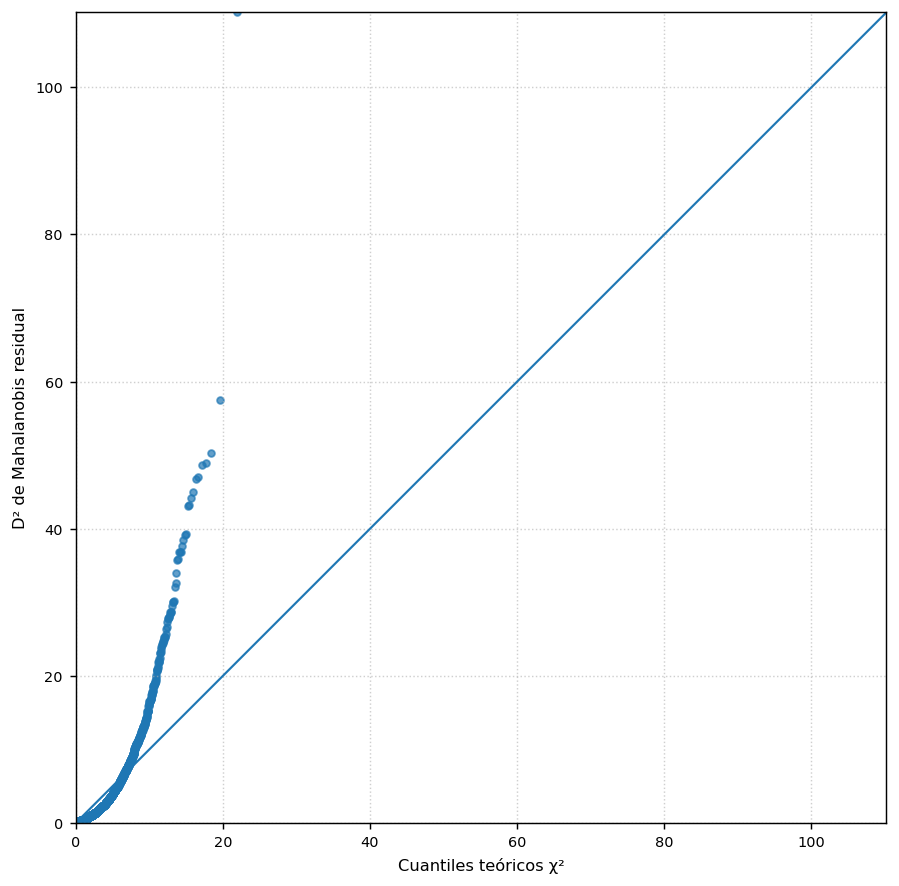


Interpretación metodológica:
Las pruebas de Mardia rechazan la normalidad multivariada de los residuos.
En consecuencia, la inferencia exacta bajo normalidad no debe interpretarse de forma estricta.
Por robustez relativa, se privilegia la traza de Pillai como estadístico principal,
y su interpretación se complementa con el análisis de sensibilidad del modelo.

Resumen descriptivo de D² residual:


,D2_RESID
count,2469.000000
mean,4.000000
std,6.168870
min,0.042177
90%,9.204107
95%,13.842526
97.5%,21.000423
99%,30.041430
max,110.168624


In [11]:
# ==========================================
# CELDA 11 — NORMALIDAD MULTIVARIADA DE RESIDUOS
# ==========================================

# --- Marco inferencial: normalidad multivariada de los residuos ---
# H_0: u_i ~ N_p(0, Sigma),  i = 1,...,n  (residuos normales multivariados)
# H_1: la distribucion residual se aparta de la normalidad.
# Pruebas de Mardia:
#   - Asimetria:  n*b_{1,p}/6  ~  chi^2  con  nu = p(p+1)(p+2)/6
#   - Curtosis:   Z = (b_{2,p} - p(p+2))/sqrt(8p(p+2)/n)  ~  N(0,1)
# Regla: rechazar H_0 si p_skew < alpha  o  p_kurt < alpha.
print("=== Pruebas de normalidad multivariada (Mardia) ===")
print("H_0: u_i ~ N_p(0, Sigma)   vs   H_1: distribucion residual no normal multivariada")
print(f"Nivel: alpha = {ALPHA}")
print()


mardia_raw, D2_resid = mardia_test(U_hat)

dfm["D2_RESID"] = D2_resid

mardia_descriptivos = pd.DataFrame({
    "tipo": ["descriptivo", "descriptivo"],
    "componente": ["Asimetría de Mardia (b1,p)", "Curtosis de Mardia (b2,p)"],
    "estadistico": ["b1,p", "b2,p"],
    "valor": [
        float(mardia_raw.loc[mardia_raw["estadistico"] == "Mardia_skewness", "valor"].iloc[0]),
        float(mardia_raw.loc[mardia_raw["estadistico"] == "Mardia_kurtosis", "valor"].iloc[0])
    ],
    "gl": [np.nan, np.nan],
    "p_value": [np.nan, np.nan]
})

mardia_inferenciales = pd.DataFrame({
    "tipo": ["inferencia", "inferencia"],
    "componente": ["Chi-cuadrado para asimetría", "Z para curtosis"],
    "estadistico": ["Chi2_skew", "Z_kurtosis"],
    "valor": [
        float(mardia_raw.loc[mardia_raw["estadistico"] == "Chi2_skew", "valor"].iloc[0]),
        float(mardia_raw.loc[mardia_raw["estadistico"] == "Z_kurtosis", "valor"].iloc[0])
    ],
    "gl": [
        float(mardia_raw.loc[mardia_raw["estadistico"] == "Chi2_skew", "gl"].iloc[0]),
        np.nan
    ],
    "p_value": [
        float(mardia_raw.loc[mardia_raw["estadistico"] == "Chi2_skew", "p_value"].iloc[0]),
        float(mardia_raw.loc[mardia_raw["estadistico"] == "Z_kurtosis", "p_value"].iloc[0])
    ]
})

mardia_export = pd.concat([mardia_descriptivos, mardia_inferenciales], axis=0, ignore_index=True)

print("Estadísticos descriptivos de Mardia:")
display(mardia_descriptivos)

print("Pruebas inferenciales de Mardia:")
display(mardia_inferenciales)

chi2_cut_975 = chi2.ppf(0.975, df=m)
chi2_cut_990 = chi2.ppf(0.990, df=m)

print("Umbrales χ² de referencia para D² residual:")
print(f"χ²_{{{m}, 0.975}} = {chi2_cut_975:.6f}")
print(f"χ²_{{{m}, 0.990}} = {chi2_cut_990:.6f}")

print(f"\nMunicipios con D² > χ²_0.975: {(dfm['D2_RESID'] > chi2_cut_975).sum()}")
print(f"Municipios con D² > χ²_0.990: {(dfm['D2_RESID'] > chi2_cut_990).sum()}")

D2_sorted = np.sort(D2_resid)
chi2_theoretical = chi2.ppf((np.arange(1, n + 1) - 0.5) / n, df=m)

plt.figure(figsize=(7, 7))
plt.scatter(chi2_theoretical, D2_sorted, s=14, alpha=0.70)
lim_sup = max(float(np.max(chi2_theoretical)), float(np.max(D2_sorted)))
plt.plot([0, lim_sup], [0, lim_sup], linewidth=1.2)
plt.xlim(0, lim_sup)
plt.ylim(0, lim_sup)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Cuantiles teóricos χ²")
plt.ylabel("D² de Mahalanobis residual")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

p_mardia_skew = mardia_inferenciales.loc[
    mardia_inferenciales["componente"] == "Chi-cuadrado para asimetría", "p_value"
].iloc[0]

p_mardia_kurt = mardia_inferenciales.loc[
    mardia_inferenciales["componente"] == "Z para curtosis", "p_value"
].iloc[0]

print("\nInterpretación metodológica:")
if (p_mardia_skew < ALPHA) or (p_mardia_kurt < ALPHA):
    print(
        "Las pruebas de Mardia rechazan la normalidad multivariada de los residuos.\n"
        "En consecuencia, la inferencia exacta bajo normalidad no debe interpretarse de forma estricta.\n"
        "Por robustez relativa, se privilegia la traza de Pillai como estadístico principal,\n"
        "y su interpretación se complementa con el análisis de sensibilidad del modelo."
    )
else:
    print(
        "No se detecta evidencia suficiente contra la normalidad multivariada de los residuos.\n"
        "Aun así, el supuesto debe interpretarse junto con el Q-Q plot y los diagnósticos de influencia."
    )

resumen_D2 = pd.Series(D2_resid).describe(percentiles=[0.90, 0.95, 0.975, 0.99]).to_frame("D2_RESID")
print("\nResumen descriptivo de D² residual:")
display(resumen_D2)

In [12]:
# ==========================================
# CELDA 12 — DIAGNÓSTICO AUXILIAR DE HETEROCEDASTICIDAD
# ==========================================

# --- Marco inferencial: homocedasticidad multivariada ---
# H_0: Cov(u_i) = Sigma  es constante para todo i  (homocedasticidad)
# H_1: la covarianza residual depende de las covariables (heterocedasticidad)
# Diagnostico auxiliar tipo White multivariado sobre vech(u_i u_i').
# Regla: rechazar H_0 si p_pillai_auxiliar < alpha.
print("=== Diagnostico auxiliar de homocedasticidad (tipo White multivariado) ===")
print("H_0: Cov(u_i) = Sigma constante   vs   H_1: heterocedasticidad")
print(f"Nivel: alpha = {ALPHA}")
print()


G = []
for i in range(n):
    Ui = U_hat[i, :].reshape(-1, 1)
    Gi = vech_symmetric(Ui @ Ui.T)
    G.append(Gi)

G = np.vstack(G)

W, W_names = make_white_design(Z)

fit_aux_full = fit_multivariate_ols(W, G)
E_aux_full = fit_aux_full["E_mat"]

W_reduced = W[:, [0]]
fit_aux_red = fit_multivariate_ols(W_reduced, G)
E_aux_red = fit_aux_red["E_mat"]

H_aux = E_aux_red - E_aux_full
stats_white = multivariate_test_stats(E_aux_full, H_aux, fit_aux_full["gl_error"])

white_df = pd.DataFrame({
    "estadistico": ["Wilks_Lambda", "Pillai_Trace", "F_Wilks", "p_Wilks", "F_Pillai", "p_Pillai"],
    "valor": [
        stats_white["Wilks"],
        stats_white["Pillai"],
        stats_white["F_Wilks"],
        stats_white["p_Wilks"],
        stats_white["F_Pillai"],
        stats_white["p_Pillai"]
    ]
})

print("Diagnóstico auxiliar de heterocedasticidad multivariada:")
display(white_df)

print(
    "Nota metodológica:\n"
    "Este procedimiento es una extensión auxiliar tipo White sobre vech(u_i u_i'),\n"
    "útil como diagnóstico complementario, pero no debe presentarse como una prueba clásica estándar."
)

if np.isfinite(stats_white["p_Pillai"]):
    if stats_white["p_Pillai"] < ALPHA:
        print("Se detecta evidencia de estructura heterocedástica en este diagnóstico auxiliar.")
    else:
        print("No se detecta heterocedasticidad multivariada sistemática en este diagnóstico auxiliar.")

Diagnóstico auxiliar de heterocedasticidad multivariada:


,estadistico,valor
0,Wilks_Lambda,0.289809
1,Pillai_Trace,1.120100
2,F_Wilks,32.391990
3,p_Wilks,0.000000
4,F_Pillai,28.873760
5,p_Pillai,0.000000


Nota metodológica:
Este procedimiento es una extensión auxiliar tipo White sobre vech(u_i u_i'),
útil como diagnóstico complementario, pero no debe presentarse como una prueba clásica estándar.
Se detecta evidencia de estructura heterocedástica en este diagnóstico auxiliar.


Matriz de correlación residual entre respuestas:


,PCDISC_MEN_prop_sqrt,P15YM_AN_prop_sqrt,PDESOCUP_prop_sqrt,VPH_SNBIEN_prop_sqrt
PCDISC_MEN_prop_sqrt,1.000000,0.272425,-0.098445,0.193362
P15YM_AN_prop_sqrt,0.272425,1.000000,-0.060831,0.306281
PDESOCUP_prop_sqrt,-0.098445,-0.060831,1.000000,0.106516
VPH_SNBIEN_prop_sqrt,0.193362,0.306281,0.106516,1.000000


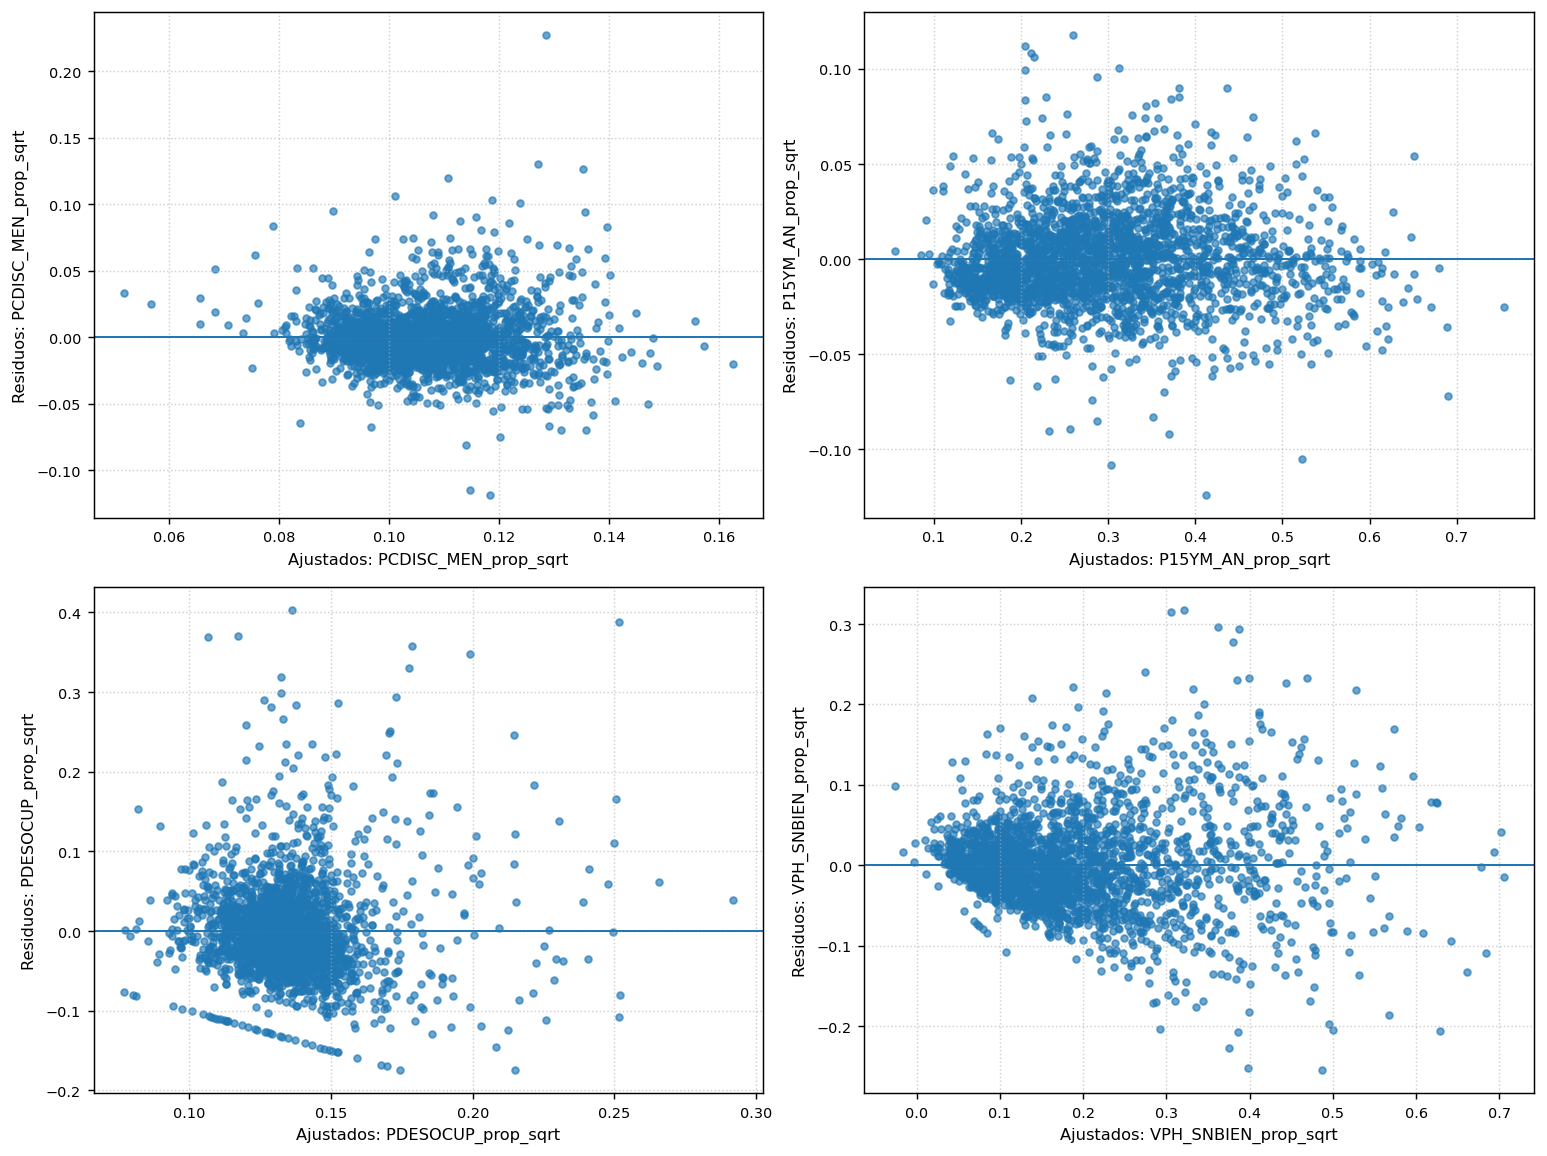

In [13]:
# ==========================================
# CELDA 13 — DIAGNÓSTICO ESTRUCTURAL DE RESIDUOS
# ==========================================

corr_resid = np.corrcoef(U_hat, rowvar=False)
corr_resid_df = pd.DataFrame(corr_resid, index=Y_sqrt_vars, columns=Y_sqrt_vars)

print("Matriz de correlación residual entre respuestas:")
display(corr_resid_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, y_name in enumerate(Y_sqrt_vars):
    fit_col = f"{y_name}_fit"
    resid_col = f"{y_name}_resid"

    ax = axes[i]
    ax.scatter(dfm[fit_col], dfm[resid_col], s=14, alpha=0.65)
    ax.axhline(0, linewidth=1.1)
    ax.set_xlabel(f"Ajustados: {y_name}", fontsize=9)
    ax.set_ylabel(f"Residuos: {y_name}", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

Umbrales de leverage:
2q/n = 0.008910
3q/n = 0.013366

Umbral de Cook multivariada: 4/n = 0.001620
Casos con leverage > 2q/n: 226
Casos con Cook > 4/n: 1226

Resumen de medidas de influencia:


,LEVERAGE,D2_X,D2_RESID,COOK_MULTI
count,2469.000000,2469.000000,2469.000000,2469.000000
mean,0.004455,9.995950,4.000000,0.006538
std,0.003987,9.840250,6.168870,0.017368
min,0.000743,0.834688,0.042177,0.000014
90%,0.008354,19.618978,9.204107,0.015081
95%,0.011083,26.352277,13.842526,0.028267
97.5%,0.014940,35.872201,21.000423,0.045341
99%,0.022806,55.286114,30.041430,0.071199
max,0.047199,115.487492,110.168624,0.386783



Municipios más influyentes:


,NOM_ENT,NOM_MUN,LEVERAGE,D2_X,D2_RESID,COOK_MULTI
121651,Oaxaca,San Simón Zahuatlán,0.028964,70.483024,50.366632,0.386783
74598,Guerrero,Cochoapa el Grande,0.022833,55.352984,43.142109,0.257913
26961,Chiapas,Mitontic,0.026280,63.859618,28.692133,0.198821
124259,Oaxaca,Santiago Nejapilla,0.006849,15.904900,110.168624,0.191260
120707,Oaxaca,San Pedro Jaltepetongo,0.014505,34.799430,48.642140,0.181623
55112,Durango,Mezquital,0.047199,115.487492,12.357416,0.160619
123667,Oaxaca,Santiago Amoltepec,0.012591,30.074859,48.903973,0.157888
124191,Oaxaca,Santiago Llano Grande,0.031483,76.699262,18.647004,0.156460
119061,Oaxaca,San Juan Mixtepec,0.012619,30.143904,45.024229,0.145693
120400,Oaxaca,San Miguel Yotao,0.010662,25.315134,47.063464,0.128171


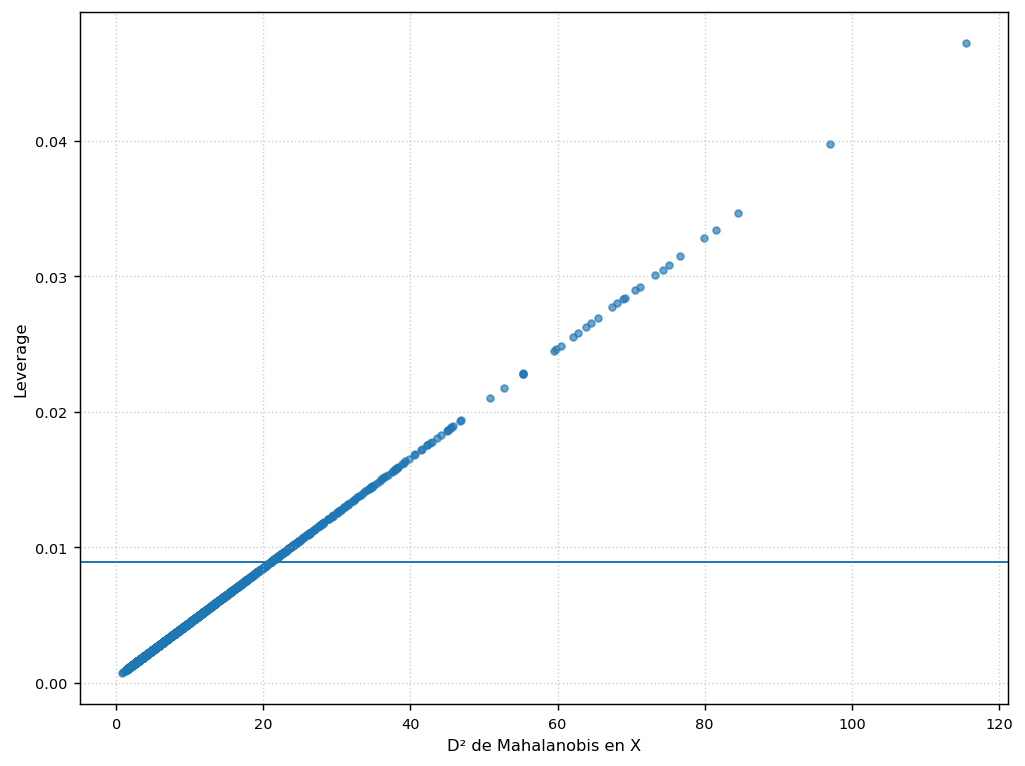

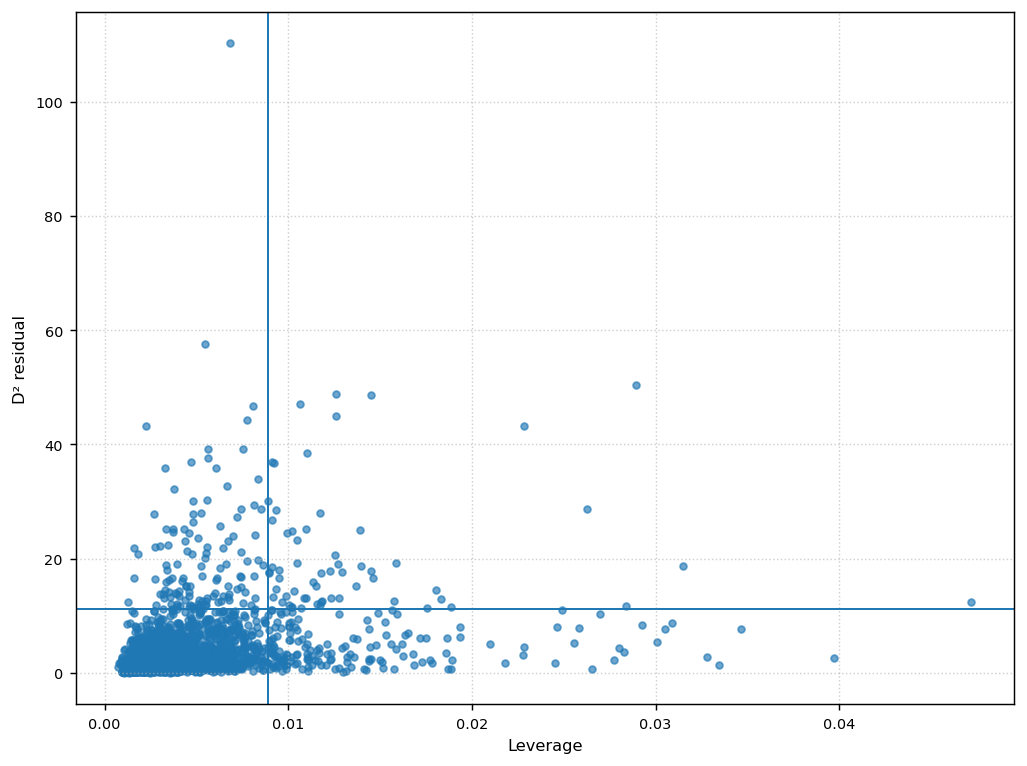

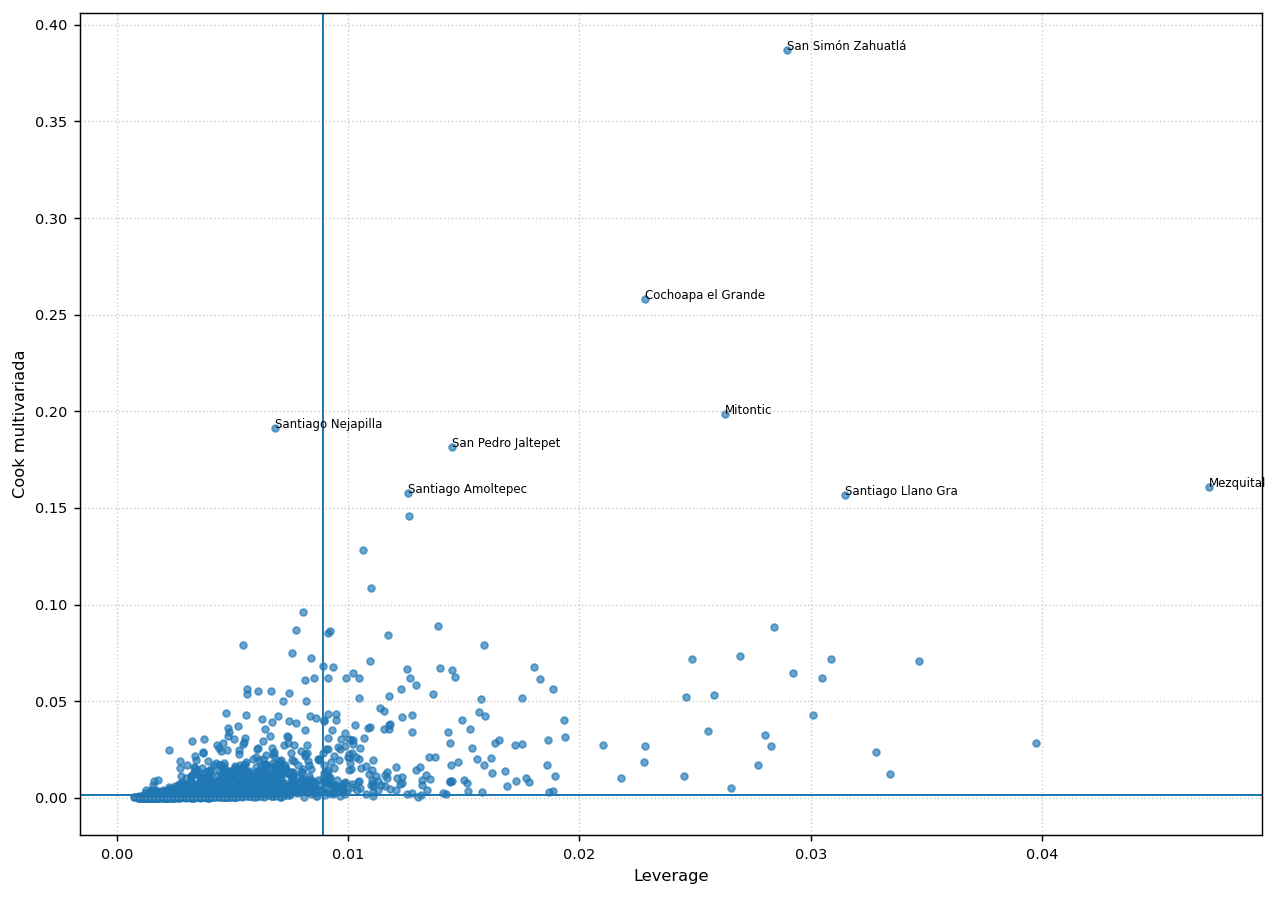

In [14]:
# ==========================================
# CELDA 14 — INFLUENCIA MULTIVARIADA
# ==========================================

H_x = X @ XtX_inv @ X.T
leverage = np.diag(H_x)
dfm["LEVERAGE"] = leverage

lev_cut = 2 * q / n
lev_cut_alt = 3 * q / n

print("Umbrales de leverage:")
print(f"2q/n = {lev_cut:.6f}")
print(f"3q/n = {lev_cut_alt:.6f}")

Z_centered = Z - Z.mean(axis=0, keepdims=True)
S_z = np.cov(Z_centered, rowvar=False, ddof=1)
S_z_inv = inv(S_z)

D2_X = np.einsum("ij,jk,ik->i", Z_centered, S_z_inv, Z_centered)
dfm["D2_X"] = D2_X

Cook_multi = (leverage / (m * (1.0 - leverage)**2)) * dfm["D2_RESID"].to_numpy()
dfm["COOK_MULTI"] = Cook_multi

cook_cut_4n = 4 / n

print(f"\nUmbral de Cook multivariada: 4/n = {cook_cut_4n:.6f}")
print(f"Casos con leverage > 2q/n: {(dfm['LEVERAGE'] > lev_cut).sum()}")
print(f"Casos con Cook > 4/n: {(dfm['COOK_MULTI'] > cook_cut_4n).sum()}")

resumen_influencia = dfm[["LEVERAGE", "D2_X", "D2_RESID", "COOK_MULTI"]].describe(
    percentiles=[0.90, 0.95, 0.975, 0.99]
)

print("\nResumen de medidas de influencia:")
display(resumen_influencia)

cols_inf = [c for c in ["NOM_ENT", "NOM_MUN", "LEVERAGE", "D2_X", "D2_RESID", "COOK_MULTI"] if c in dfm.columns]
print("\nMunicipios más influyentes:")
display(dfm[cols_inf].sort_values("COOK_MULTI", ascending=False).head(20))

plt.figure(figsize=(8, 6))
plt.scatter(dfm["D2_X"], dfm["LEVERAGE"], s=14, alpha=0.65)
plt.axhline(lev_cut, linewidth=1.1)
plt.xlabel("D² de Mahalanobis en X")
plt.ylabel("Leverage")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(dfm["LEVERAGE"], dfm["D2_RESID"], s=14, alpha=0.65)
plt.axvline(lev_cut, linewidth=1.1)
plt.axhline(chi2_cut_975, linewidth=1.1)
plt.xlabel("Leverage")
plt.ylabel("D² residual")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

top_idx = dfm["COOK_MULTI"].sort_values(ascending=False).head(8).index

plt.figure(figsize=(10, 7))
plt.scatter(dfm["LEVERAGE"], dfm["COOK_MULTI"], s=14, alpha=0.65)
plt.axhline(cook_cut_4n, linewidth=1.1)
plt.axvline(lev_cut, linewidth=1.1)

for idx in top_idx:
    nombre = str(dfm.loc[idx, "NOM_MUN"]) if "NOM_MUN" in dfm.columns else str(idx)
    plt.text(
        dfm.loc[idx, "LEVERAGE"],
        dfm.loc[idx, "COOK_MULTI"],
        nombre[:18],
        fontsize=6.5
    )

plt.xlabel("Leverage")
plt.ylabel("Cook multivariada")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# CELDA 15 — ANÁLISIS DE SENSIBILIDAD
# ==========================================

idx_influyentes = dfm.index[dfm["COOK_MULTI"] > cook_cut_4n].tolist()

print(f"Número de municipios influyentes detectados: {len(idx_influyentes)}")

if len(idx_influyentes) > 0:
    cols_show = [c for c in ["NOM_ENT", "NOM_MUN", "LEVERAGE", "D2_RESID", "COOK_MULTI"] if c in dfm.columns]
    display(dfm.loc[idx_influyentes, cols_show].sort_values("COOK_MULTI", ascending=False).head(20))

dfm_sens = dfm.drop(index=idx_influyentes).copy()

Y_sens = dfm_sens[Y_sqrt_vars].to_numpy(dtype=float)
X_raw_sens = dfm_sens[X_sqrt_vars].to_numpy(dtype=float)

Z_sens = (X_raw_sens - X_mean) / X_std
X_sens = np.column_stack([np.ones(X_raw_sens.shape[0]), Z_sens])

fit_sens = fit_multivariate_ols(X_sens, Y_sens)

B_hat_sens = fit_sens["B_hat"]
Sigma_hat_sens = fit_sens["Sigma_hat"]
T_sens = fit_sens["T_mat"]
E_sens = fit_sens["E_mat"]
H_sens = fit_sens["H_mat"]
gl_error_sens = fit_sens["gl_error"]

stats_sens = multivariate_test_stats(E_sens, H_sens, gl_error_sens)
R2_trace_sens = np.trace(H_sens) / np.trace(T_sens)

B_hat_sens_df = pd.DataFrame(B_hat_sens, index=["Intercepto"] + X_sqrt_vars, columns=Y_sqrt_vars)
Sigma_hat_sens_df = pd.DataFrame(Sigma_hat_sens, index=Y_sqrt_vars, columns=Y_sqrt_vars)

coef_diff_abs = (B_hat_sens_df - B_hat_df).abs()
coef_diff_rel = coef_diff_abs / (B_hat_df.abs() + 1e-12)
Sigma_diff_abs = (Sigma_hat_sens_df - Sigma_hat_df).abs()

resumen_sens = pd.DataFrame({
    "métrica": ["n", "gl_error", "R2_trace", "Wilks_Lambda", "Pillai_Trace"],
    "modelo_original": [n, gl_error, R2_trace, stats_global["Wilks"], stats_global["Pillai"]],
    "modelo_sin_influyentes": [
        X_sens.shape[0],
        gl_error_sens,
        R2_trace_sens,
        stats_sens["Wilks"],
        stats_sens["Pillai"]
    ]
})

print("Resumen comparativo del análisis de sensibilidad:")
display(resumen_sens)

print("\nDiferencia absoluta en coeficientes:")
display(coef_diff_abs)

print("\nDiferencia relativa en coeficientes:")
display(coef_diff_rel)

print("\nDiferencia absoluta en Sigma_hat:")
display(Sigma_diff_abs)

cambio_max_coef = pd.DataFrame({
    "predictor": coef_diff_abs.index,
    "max_diff_abs": coef_diff_abs.max(axis=1).values,
    "max_diff_rel": coef_diff_rel.max(axis=1).values
}).sort_values("max_diff_rel", ascending=False)

print("\nCambio máximo por predictor:")
display(cambio_max_coef)

delta_r2 = abs(R2_trace_sens - R2_trace)
print(f"\n|Δ R²_trace| = {delta_r2:.6f}")
if delta_r2 < 0.02:
    print("El ajuste global luce estable frente a la eliminación de casos influyentes.")
else:
    print("El ajuste global cambia de manera apreciable; conviene discutir sensibilidad en la tesis.")

Número de municipios influyentes detectados: 1226


,NOM_ENT,NOM_MUN,LEVERAGE,D2_RESID,COOK_MULTI
121651,Oaxaca,San Simón Zahuatlán,0.028964,50.366632,0.386783
74598,Guerrero,Cochoapa el Grande,0.022833,43.142109,0.257913
26961,Chiapas,Mitontic,0.026280,28.692133,0.198821
124259,Oaxaca,Santiago Nejapilla,0.006849,110.168624,0.191260
120707,Oaxaca,San Pedro Jaltepetongo,0.014505,48.642140,0.181623
55112,Durango,Mezquital,0.047199,12.357416,0.160619
123667,Oaxaca,Santiago Amoltepec,0.012591,48.903973,0.157888
124191,Oaxaca,Santiago Llano Grande,0.031483,18.647004,0.156460
119061,Oaxaca,San Juan Mixtepec,0.012619,45.024229,0.145693
120400,Oaxaca,San Miguel Yotao,0.010662,47.063464,0.128171


Resumen comparativo del análisis de sensibilidad:


,métrica,modelo_original,modelo_sin_influyentes
0,n,2469.000000,1243.000000
1,gl_error,2458.000000,1232.000000
2,R2_trace,0.769614,0.855325
3,Wilks_Lambda,0.014891,0.007674
4,Pillai_Trace,1.745274,1.878959



Diferencia absoluta en coeficientes:


...


Diferencia absoluta en Sigma_hat:


,PCDISC_MEN_prop_sqrt,P15YM_AN_prop_sqrt,PDESOCUP_prop_sqrt,VPH_SNBIEN_prop_sqrt
PCDISC_MEN_prop_sqrt,0.000366,0.000101,0.000112,0.000223
P15YM_AN_prop_sqrt,0.000101,0.000396,0.000096,0.000282
PDESOCUP_prop_sqrt,0.000112,0.000096,0.002777,0.000260
VPH_SNBIEN_prop_sqrt,0.000223,0.000282,0.000260,0.002614



Cambio máximo por predictor:


,predictor,max_diff_abs,max_diff_rel
2,VPH_NDEAED_prop_sqrt,0.004648,6.823076
6,POB_AFRO_prop_sqrt,0.001725,5.191701
8,P15YM_SE_prop_sqrt,0.007772,3.935173
10,PRESOE15_prop_sqrt,0.002330,3.051168
3,PRO_OCUP_C_prop_sqrt,0.002940,1.499888
4,P3HLINHE_prop_sqrt,0.004510,1.228013
1,VPH_PISOTI_prop_sqrt,0.016259,1.209506
9,PSIN_RELIG_prop_sqrt,0.001462,1.148330
5,PHOG_IND_prop_sqrt,0.007303,0.688031
7,PSINDER_prop_sqrt,0.009312,0.603891



|Δ R²_trace| = 0.085711
El ajuste global cambia de manera apreciable; conviene discutir sensibilidad en la tesis.


Autovalores canónicos:
[22.500903  1.198835  0.208738  0.075177]

Verificación A'EA para todas las direcciones canónicas:
[[ 1. -0. -0.  0.]
 [-0.  1.  0. -0.]
 [-0.  0.  1. -0.]
 [ 0. -0. -0.  1.]]


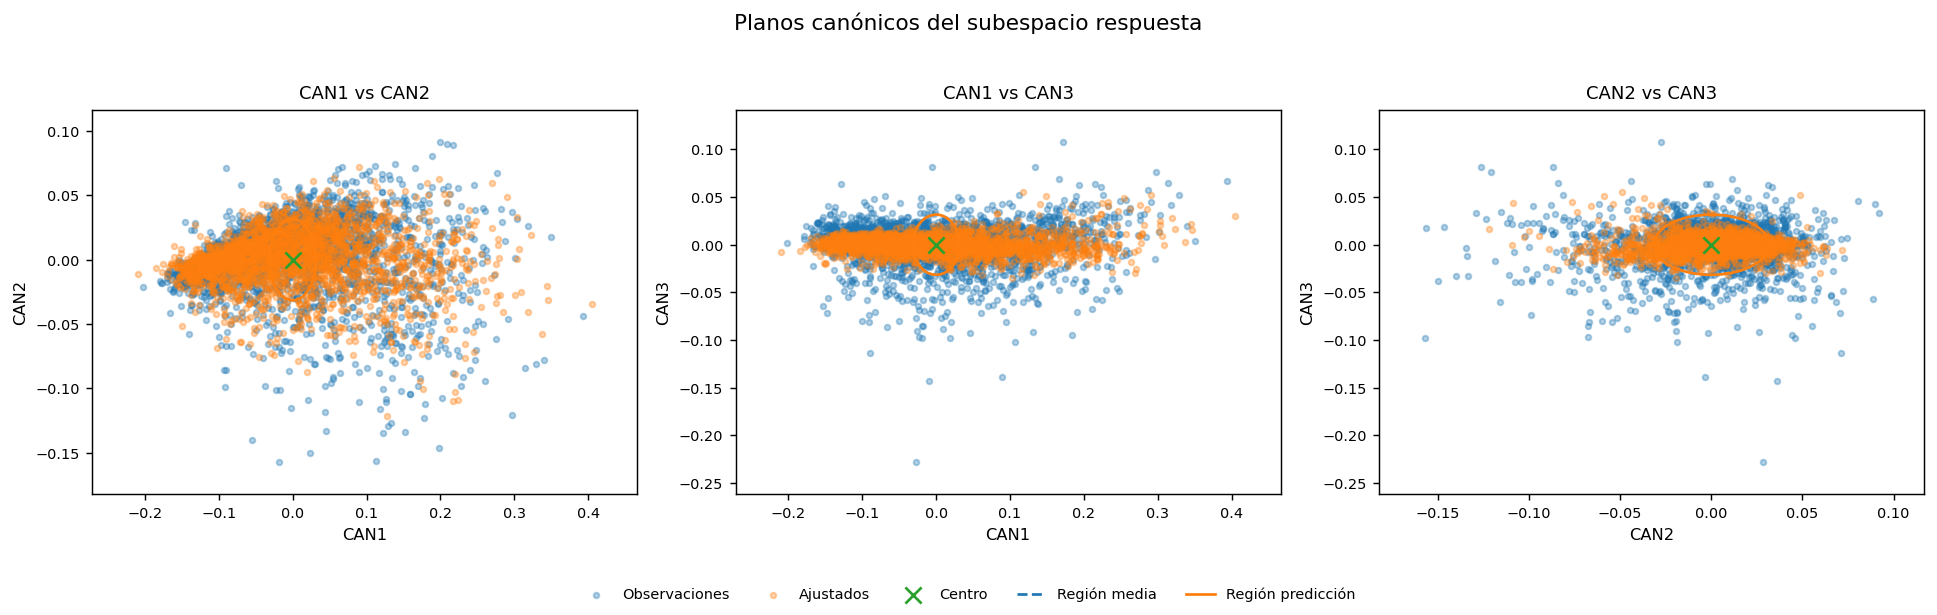

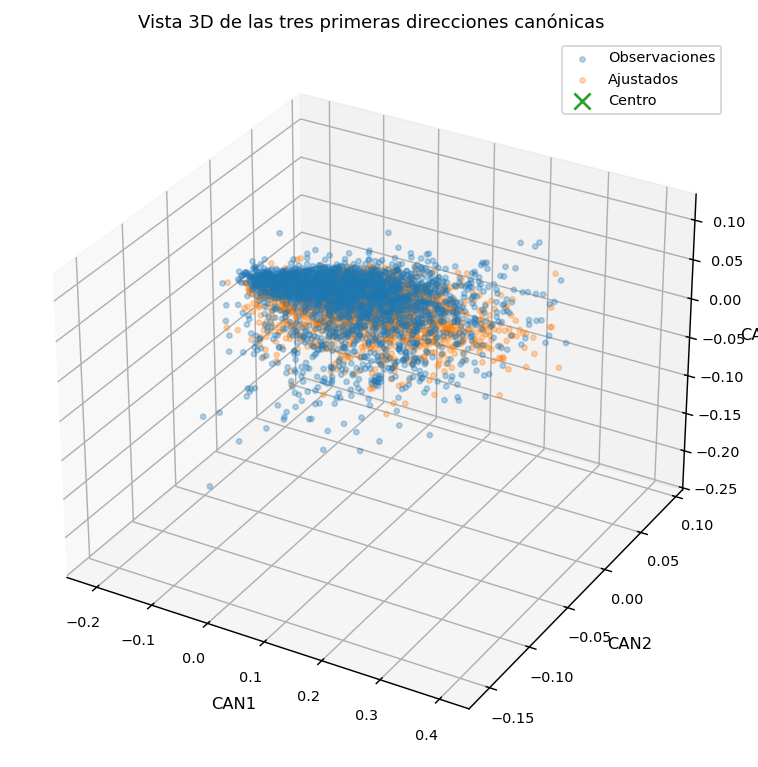

Resumen de las coordenadas canónicas observadas:


,count,mean,std,min,25%,50%,75%,max
CAN1,2469.0,-1.223089e-17,0.097582,-0.202603,-0.074978,-0.011500,0.060187,0.393084
CAN2,2469.0,-1.151143e-17,0.029849,-0.157138,-0.012618,0.003161,0.017614,0.091761
CAN3,2469.0,-1.079196e-18,0.022131,-0.227998,-0.008252,0.002596,0.012560,0.108189
CAN4,2469.0,-2.922823e-18,0.020872,-0.144455,-0.007710,0.002383,0.012022,0.071931


Resumen de las coordenadas canónicas ajustadas:


,count,mean,std,min,25%,50%,75%,max
CAN1,2469.0,-1.510875e-17,0.095483,-0.209740,-0.071814,-0.012763,0.055206,0.404675
CAN2,2469.0,-2.877856e-18,0.022040,-0.121628,-0.010615,0.000724,0.013249,0.071746
CAN3,2469.0,-1.393962e-17,0.009197,-0.035288,-0.005271,0.000155,0.005095,0.054901
CAN4,2469.0,-4.496651e-18,0.005519,-0.028270,-0.003443,-0.000241,0.003258,0.018542


Resumen de los residuos en coordenadas canónicas:


,count,mean,std,min,25%,50%,75%,max
CAN1,2469.0,3.057722e-18,0.020129,-0.100583,-0.012249,-0.001577,0.010683,0.110158
CAN2,2469.0,-8.093971e-18,0.020129,-0.118780,-0.008936,0.000736,0.010521,0.102465
CAN3,2469.0,1.241076e-17,0.020129,-0.209439,-0.008519,0.001343,0.010954,0.112175
CAN4,2469.0,1.888593e-18,0.020129,-0.138452,-0.007883,0.002234,0.011341,0.072347


In [16]:
# ==========================================
# CELDA 16 — VISTAS ALTERNATIVAS DEL SUBESPACIO CANÓNICO
#  - Planos CAN1-CAN2, CAN1-CAN3, CAN2-CAN3
#  - Vista 3D de las tres primeras direcciones canónicas
#  - Versión final coherente con el flujo completo del notebook
# ==========================================

# ------------------------------------------------------------
# 1) OBJETOS FUNDAMENTALES DEL PROBLEMA CANÓNICO
# ------------------------------------------------------------
Y_bar_vec = Y.mean(axis=0, keepdims=True)

H_sym = 0.5 * (
    ((Y_hat - Y_bar_vec).T @ (Y_hat - Y_bar_vec))
    + ((Y_hat - Y_bar_vec).T @ (Y_hat - Y_bar_vec)).T
)
E_sym = 0.5 * ((U_hat.T @ U_hat) + (U_hat.T @ U_hat).T)

# ------------------------------------------------------------
# 2) CONSTRUCCIÓN DE E^{-1/2}
# ------------------------------------------------------------
eigvals_E, eigvecs_E = np.linalg.eigh(E_sym)
eigvals_E = np.clip(eigvals_E, 1e-12, None)

E_inv_half = eigvecs_E @ np.diag(1.0 / np.sqrt(eigvals_E)) @ eigvecs_E.T

# ------------------------------------------------------------
# 3) PROBLEMA CANÓNICO: E^{-1/2} H E^{-1/2}
# ------------------------------------------------------------
M_can = E_inv_half @ H_sym @ E_inv_half
M_can = 0.5 * (M_can + M_can.T)

eigvals_can, W_full = np.linalg.eigh(M_can)

order = np.argsort(eigvals_can)[::-1]
eigvals_can = eigvals_can[order]
W_full = W_full[:, order]

# Matriz completa de coeficientes canónicos
A_can_full = E_inv_half @ W_full

# Primeras direcciones para visualización
n_can_plot = min(3, m)
A_can_3d = A_can_full[:, :n_can_plot]

print("Autovalores canónicos:")
print(np.round(eigvals_can, 6))

print("\nVerificación A'EA para todas las direcciones canónicas:")
print(np.round(A_can_full.T @ E_sym @ A_can_full, 6))

# ------------------------------------------------------------
# 4) PROYECCIONES CANÓNICAS
# ------------------------------------------------------------
Y_can_full    = (Y - Y_bar_vec) @ A_can_full
Yhat_can_full = (Y_hat - Y_bar_vec) @ A_can_full
U_can_full    = U_hat @ A_can_full

Y_can_3d    = Y_can_full[:, :n_can_plot]
Yhat_can_3d = Yhat_can_full[:, :n_can_plot]
U_can_3d    = U_can_full[:, :n_can_plot]

z0_3d = np.zeros(n_can_plot)

Sigma_can_full = A_can_full.T @ Sigma_hat @ A_can_full
Sigma_can_full = 0.5 * (Sigma_can_full + Sigma_can_full.T)
Sigma_can_3d = Sigma_can_full[:n_can_plot, :n_can_plot]

# ------------------------------------------------------------
# 5) PARÁMETROS DE REGIONES
# ------------------------------------------------------------
c0 = 0.0
c_region = np.sqrt(chi2.ppf(0.95, df=2))

# ------------------------------------------------------------
# 6) FUNCIONES AUXILIARES ESPECÍFICAS DE ESTA CELDA
# ------------------------------------------------------------
def ellipse_from_axes(center3, cov3, idx_pair, c_mult):
    idx = list(idx_pair)
    center2 = np.asarray(center3)[idx]
    cov2 = np.asarray(cov3)[np.ix_(idx, idx)]
    return ellipse_points(center2, cov2, c_mult=c_mult, n_points=300)

def limites_con_margen(x, y, margen=0.10):
    x = np.asarray(x)
    y = np.asarray(y)

    xmin, xmax = np.min(x), np.max(x)
    ymin, ymax = np.min(y), np.max(y)

    dx = xmax - xmin
    dy = ymax - ymin

    if dx < 1e-12:
        dx = 1.0
    if dy < 1e-12:
        dy = 1.0

    return (
        (xmin - margen * dx, xmax + margen * dx),
        (ymin - margen * dy, ymax + margen * dy)
    )

# ------------------------------------------------------------
# 7) REGIONES PROYECTADAS PARA CADA PLANO
# ------------------------------------------------------------
Cov_mean_3d = c0 * Sigma_can_3d
Cov_pred_3d = (1.0 + c0) * Sigma_can_3d

planes = [
    ((0, 1), "CAN1", "CAN2"),
    ((0, 2), "CAN1", "CAN3"),
    ((1, 2), "CAN2", "CAN3"),
]

if n_can_plot >= 3:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    for ax, (idx_pair, xlabel, ylabel) in zip(axes, planes):
        i, j = idx_pair

        ax.scatter(Y_can_3d[:, i], Y_can_3d[:, j], s=10, alpha=0.35, label="Observaciones")
        ax.scatter(Yhat_can_3d[:, i], Yhat_can_3d[:, j], s=10, alpha=0.35, label="Ajustados")
        ax.scatter(z0_3d[i], z0_3d[j], s=80, marker="x", label="Centro")

        el_mean = ellipse_from_axes(z0_3d, Cov_mean_3d, idx_pair, c_region)
        el_pred = ellipse_from_axes(z0_3d, Cov_pred_3d, idx_pair, c_region)

        ax.plot(el_mean[:, 0], el_mean[:, 1], linestyle="--", label="Región media")
        ax.plot(el_pred[:, 0], el_pred[:, 1], linestyle="-", label="Región predicción")

        xlim, ylim = limites_con_margen(
            np.r_[Y_can_3d[:, i], Yhat_can_3d[:, i], el_pred[:, 0]],
            np.r_[Y_can_3d[:, j], Yhat_can_3d[:, j], el_pred[:, 1]]
        )
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{xlabel} vs {ylabel}")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False)
    fig.suptitle("Planos canónicos del subespacio respuesta", y=1.02)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(Y_can_3d[:, 0], Y_can_3d[:, 1], Y_can_3d[:, 2], s=8, alpha=0.30, label="Observaciones")
    ax.scatter(Yhat_can_3d[:, 0], Yhat_can_3d[:, 1], Yhat_can_3d[:, 2], s=8, alpha=0.30, label="Ajustados")
    ax.scatter(0, 0, 0, s=80, marker="x", label="Centro")

    ax.set_xlabel("CAN1")
    ax.set_ylabel("CAN2")
    ax.set_zlabel("CAN3")
    ax.set_title("Vista 3D de las tres primeras direcciones canónicas")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes direcciones canónicas para construir las vistas 3D.")

# ------------------------------------------------------------
# 8) RESUMEN NUMÉRICO DE LAS COORDENADAS CANÓNICAS
# ------------------------------------------------------------
cols_can = [f"CAN{k+1}" for k in range(m)]

df_can_scores = pd.DataFrame(Y_can_full, columns=cols_can, index=dfm.index)
df_can_scores_hat = pd.DataFrame(Yhat_can_full, columns=cols_can, index=dfm.index)
df_can_resid = pd.DataFrame(U_can_full, columns=cols_can, index=dfm.index)

print("Resumen de las coordenadas canónicas observadas:")
display(df_can_scores.describe().T)

print("Resumen de las coordenadas canónicas ajustadas:")
display(df_can_scores_hat.describe().T)

print("Resumen de los residuos en coordenadas canónicas:")
display(df_can_resid.describe().T)

Coeficientes canónicos (matriz A):


,CAN1,CAN2,CAN3,CAN4
PCDISC_MEN,-0.212586,0.205839,-0.869525,-0.300174
P15YM_AN,0.839132,0.327738,0.087898,0.013811
PDESOCUP,0.017153,0.019384,0.076632,-0.334646
VPH_SNBIEN,0.037178,-0.366911,-0.049312,0.024407



Descomposición de CAN1:


,Variable,Coeficiente,Abs,Peso_relativo
0,P15YM_AN,0.839132,0.839132,0.758675
1,PCDISC_MEN,-0.212586,0.212586,0.192203
2,VPH_SNBIEN,0.037178,0.037178,0.033613
3,PDESOCUP,0.017153,0.017153,0.015508



Descomposición de CAN2:


...

,Variable,Coeficiente,Abs,Peso_relativo
0,PDESOCUP,-0.334646,0.334646,0.497217
1,PCDISC_MEN,-0.300174,0.300174,0.445999
2,VPH_SNBIEN,0.024407,0.024407,0.036264
3,P15YM_AN,0.013811,0.013811,0.020520



Resumen de variables dominantes por dirección canónica:


,Eje,Autovalor,Correlacion_canonica,Variable_dominante,Coef_dominante,Peso_relativo_dominante,Segunda_variable,Coef_segunda,Peso_relativo_segunda
0,CAN1,22.500903,0.978493,P15YM_AN,0.839132,0.758675,PCDISC_MEN,-0.212586,0.192203
1,CAN2,1.198835,0.738386,VPH_SNBIEN,-0.366911,0.398872,P15YM_AN,0.327738,0.356287
2,CAN3,0.208738,0.415561,PCDISC_MEN,-0.869525,0.802614,P15YM_AN,0.087898,0.081134
3,CAN4,0.075177,0.264425,PDESOCUP,-0.334646,0.497217,PCDISC_MEN,-0.300174,0.445999



Tabla larga consolidada de todas las direcciones canónicas:


,Eje,Variable,Coeficiente,Abs,Peso_relativo
0,CAN1,P15YM_AN,0.839132,0.839132,0.758675
1,CAN1,PCDISC_MEN,-0.212586,0.212586,0.192203
2,CAN1,VPH_SNBIEN,0.037178,0.037178,0.033613
3,CAN1,PDESOCUP,0.017153,0.017153,0.015508
4,CAN2,VPH_SNBIEN,-0.366911,0.366911,0.398872
5,CAN2,P15YM_AN,0.327738,0.327738,0.356287
6,CAN2,PCDISC_MEN,0.205839,0.205839,0.223769
7,CAN2,PDESOCUP,0.019384,0.019384,0.021072
8,CAN3,PCDISC_MEN,-0.869525,0.869525,0.802614
9,CAN3,P15YM_AN,0.087898,0.087898,0.081134


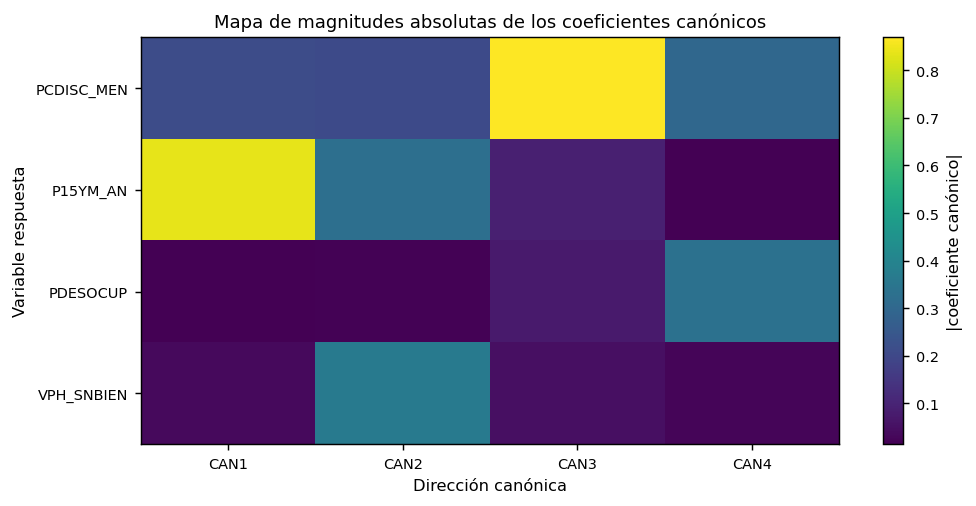

In [19]:
# ==========================================
# CELDA 17 — INTERPRETACIÓN DE TODAS LAS DIRECCIONES CANÓNICAS
# ==========================================

nombres_Y = [
    "PCDISC_MEN",
    "P15YM_AN",
    "PDESOCUP",
    "VPH_SNBIEN"
]

if len(nombres_Y) != m:
    raise ValueError("El número de nombres de respuestas no coincide con m.")

cols_can = [f"CAN{k+1}" for k in range(m)]

df_coef_can = pd.DataFrame(
    A_can_full[:, :m],
    index=nombres_Y,
    columns=cols_can
)

print("Coeficientes canónicos (matriz A):")
display(df_coef_can)

descomposiciones_can = {}

for k_can in range(m):
    nombre_can = f"CAN{k_can+1}"
    ak = A_can_full[:, k_can]

    df_k = pd.DataFrame({
        "Variable": nombres_Y,
        "Coeficiente": ak,
        "Abs": np.abs(ak)
    })

    suma_abs = df_k["Abs"].sum()
    df_k["Peso_relativo"] = df_k["Abs"] / suma_abs if suma_abs > 0 else np.nan

    df_k = df_k.sort_values("Abs", ascending=False).reset_index(drop=True)
    descomposiciones_can[nombre_can] = df_k

    print(f"\nDescomposición de {nombre_can}:")
    display(df_k)

resumen_can = []

for k_can in range(m):
    nombre_can = f"CAN{k_can+1}"
    df_k = descomposiciones_can[nombre_can]

    fila_top = df_k.iloc[0]
    fila_2 = df_k.iloc[1] if len(df_k) > 1 else None

    resumen_can.append({
        "Eje": nombre_can,
        "Autovalor": eigvals_can[k_can],
        "Correlacion_canonica": np.sqrt(eigvals_can[k_can] / (1.0 + eigvals_can[k_can])),
        "Variable_dominante": fila_top["Variable"],
        "Coef_dominante": fila_top["Coeficiente"],
        "Peso_relativo_dominante": fila_top["Peso_relativo"],
        "Segunda_variable": fila_2["Variable"] if fila_2 is not None else np.nan,
        "Coef_segunda": fila_2["Coeficiente"] if fila_2 is not None else np.nan,
        "Peso_relativo_segunda": fila_2["Peso_relativo"] if fila_2 is not None else np.nan
    })

df_resumen_can = pd.DataFrame(resumen_can)

print("\nResumen de variables dominantes por dirección canónica:")
display(df_resumen_can)

filas_largas = []
for k_can in range(m):
    nombre_can = f"CAN{k_can+1}"
    df_k = descomposiciones_can[nombre_can].copy()
    df_k.insert(0, "Eje", nombre_can)
    filas_largas.append(df_k)

df_can_long = pd.concat(filas_largas, ignore_index=True)

print("\nTabla larga consolidada de todas las direcciones canónicas:")
display(df_can_long)

plt.figure(figsize=(8, max(4, 0.65 * m)))
plt.imshow(np.abs(A_can_full[:, :m]), aspect="auto")
plt.colorbar(label="|coeficiente canónico|")
plt.xticks(ticks=np.arange(m), labels=cols_can)
plt.yticks(ticks=np.arange(m), labels=nombres_Y)
plt.xlabel("Dirección canónica")
plt.ylabel("Variable respuesta")
plt.title("Mapa de magnitudes absolutas de los coeficientes canónicos")
plt.tight_layout()
plt.show()

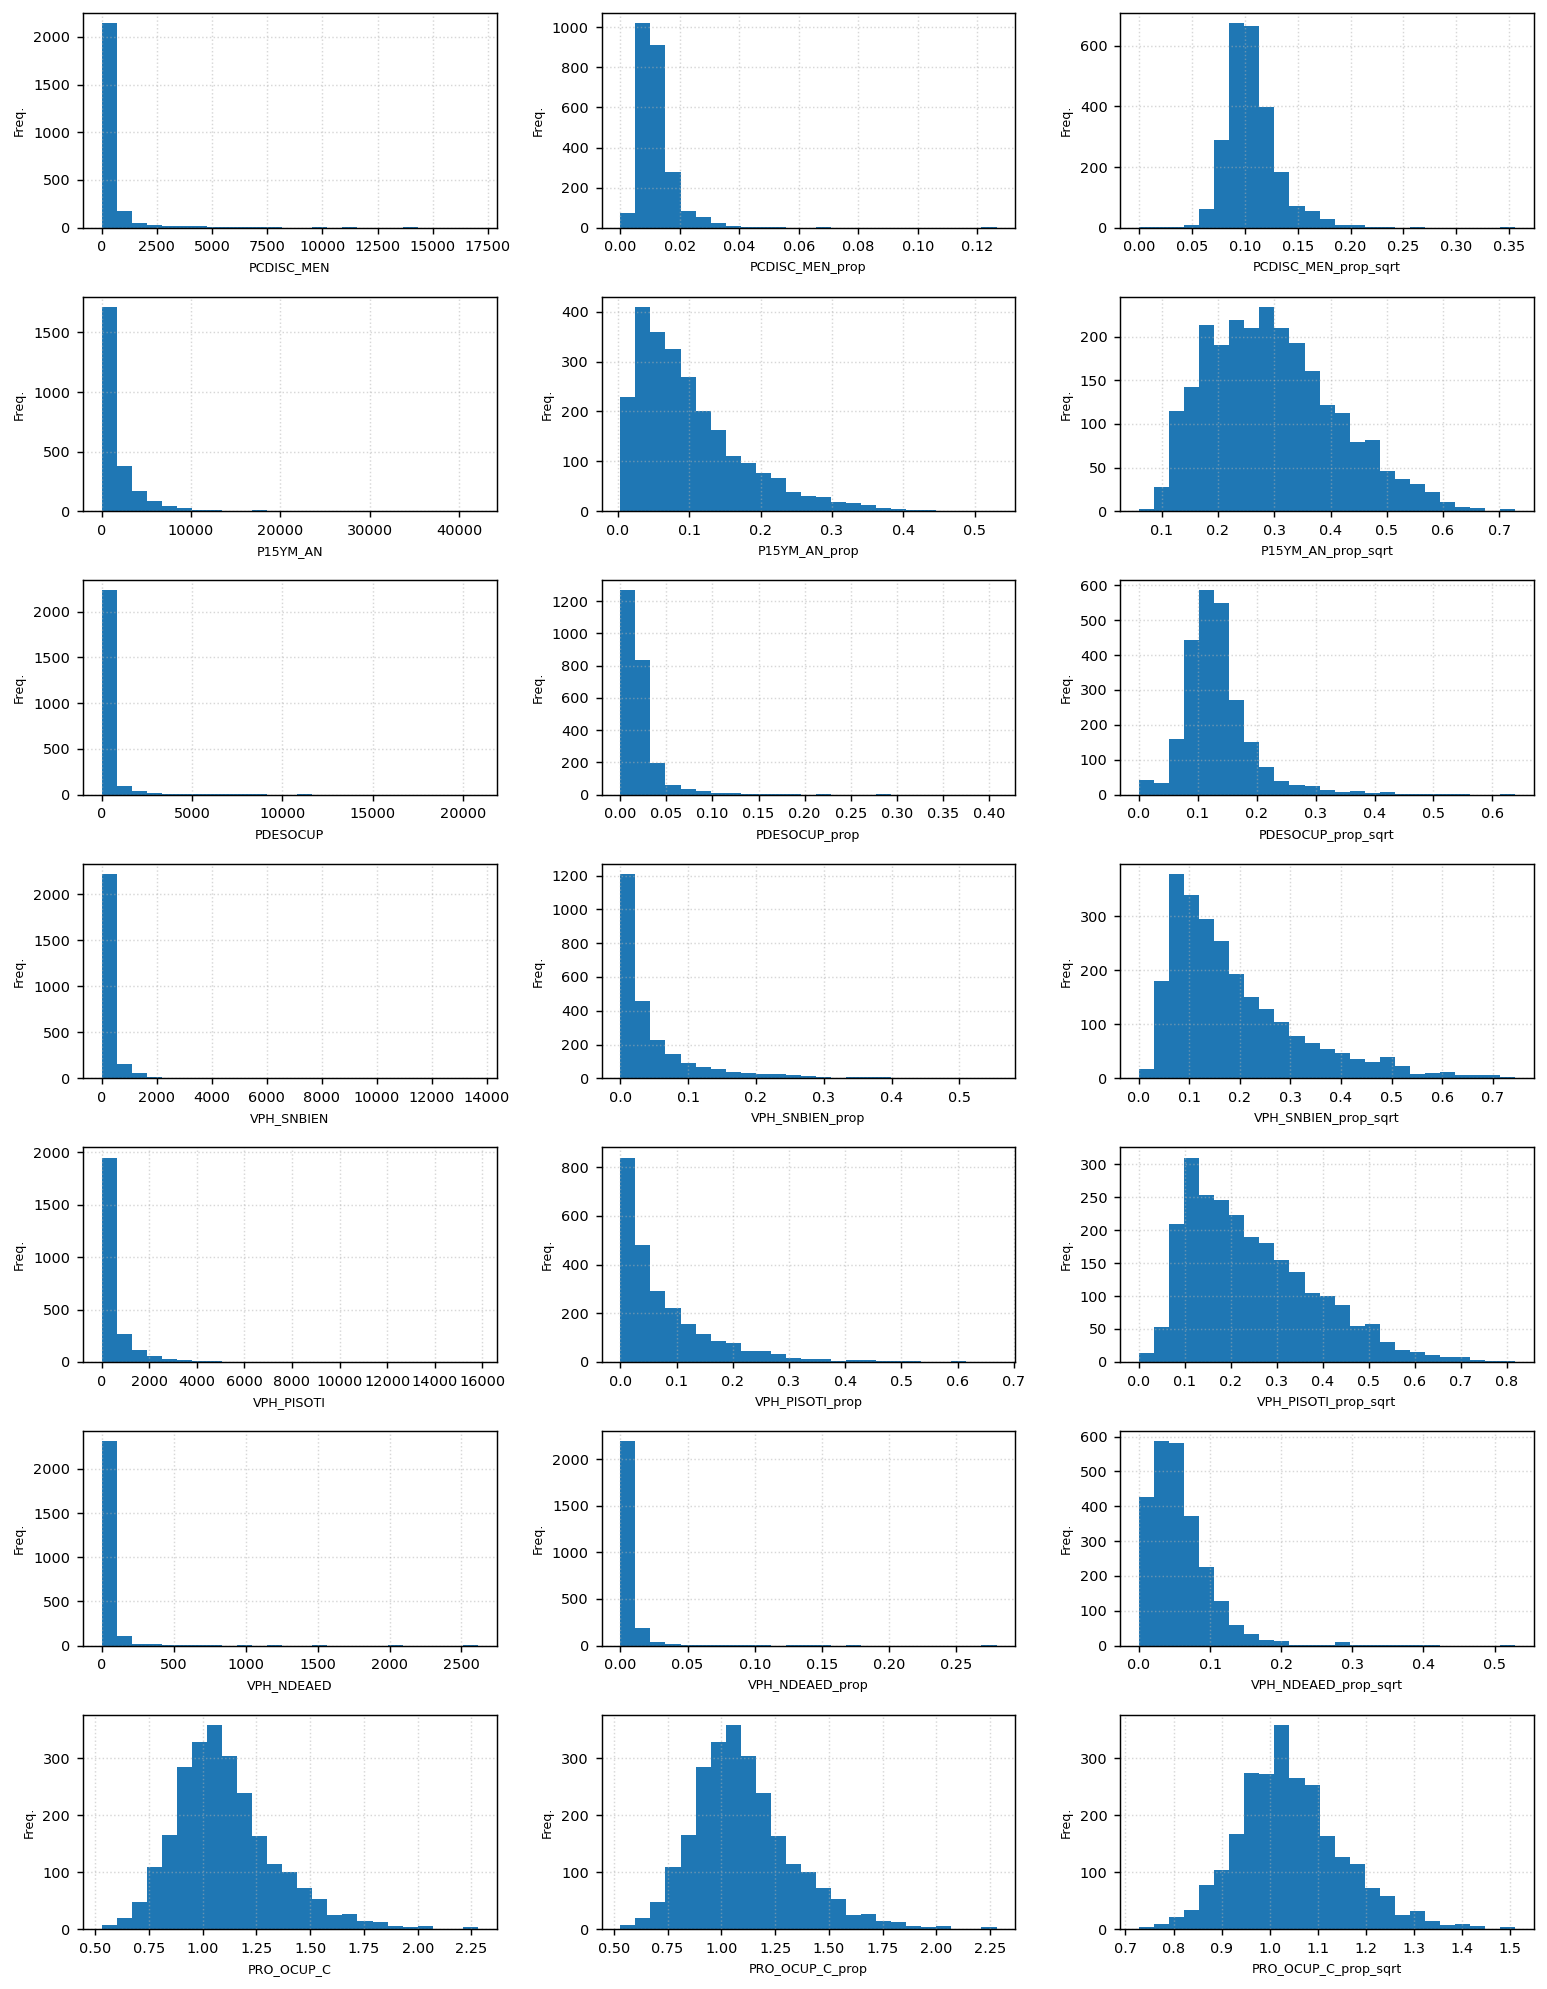

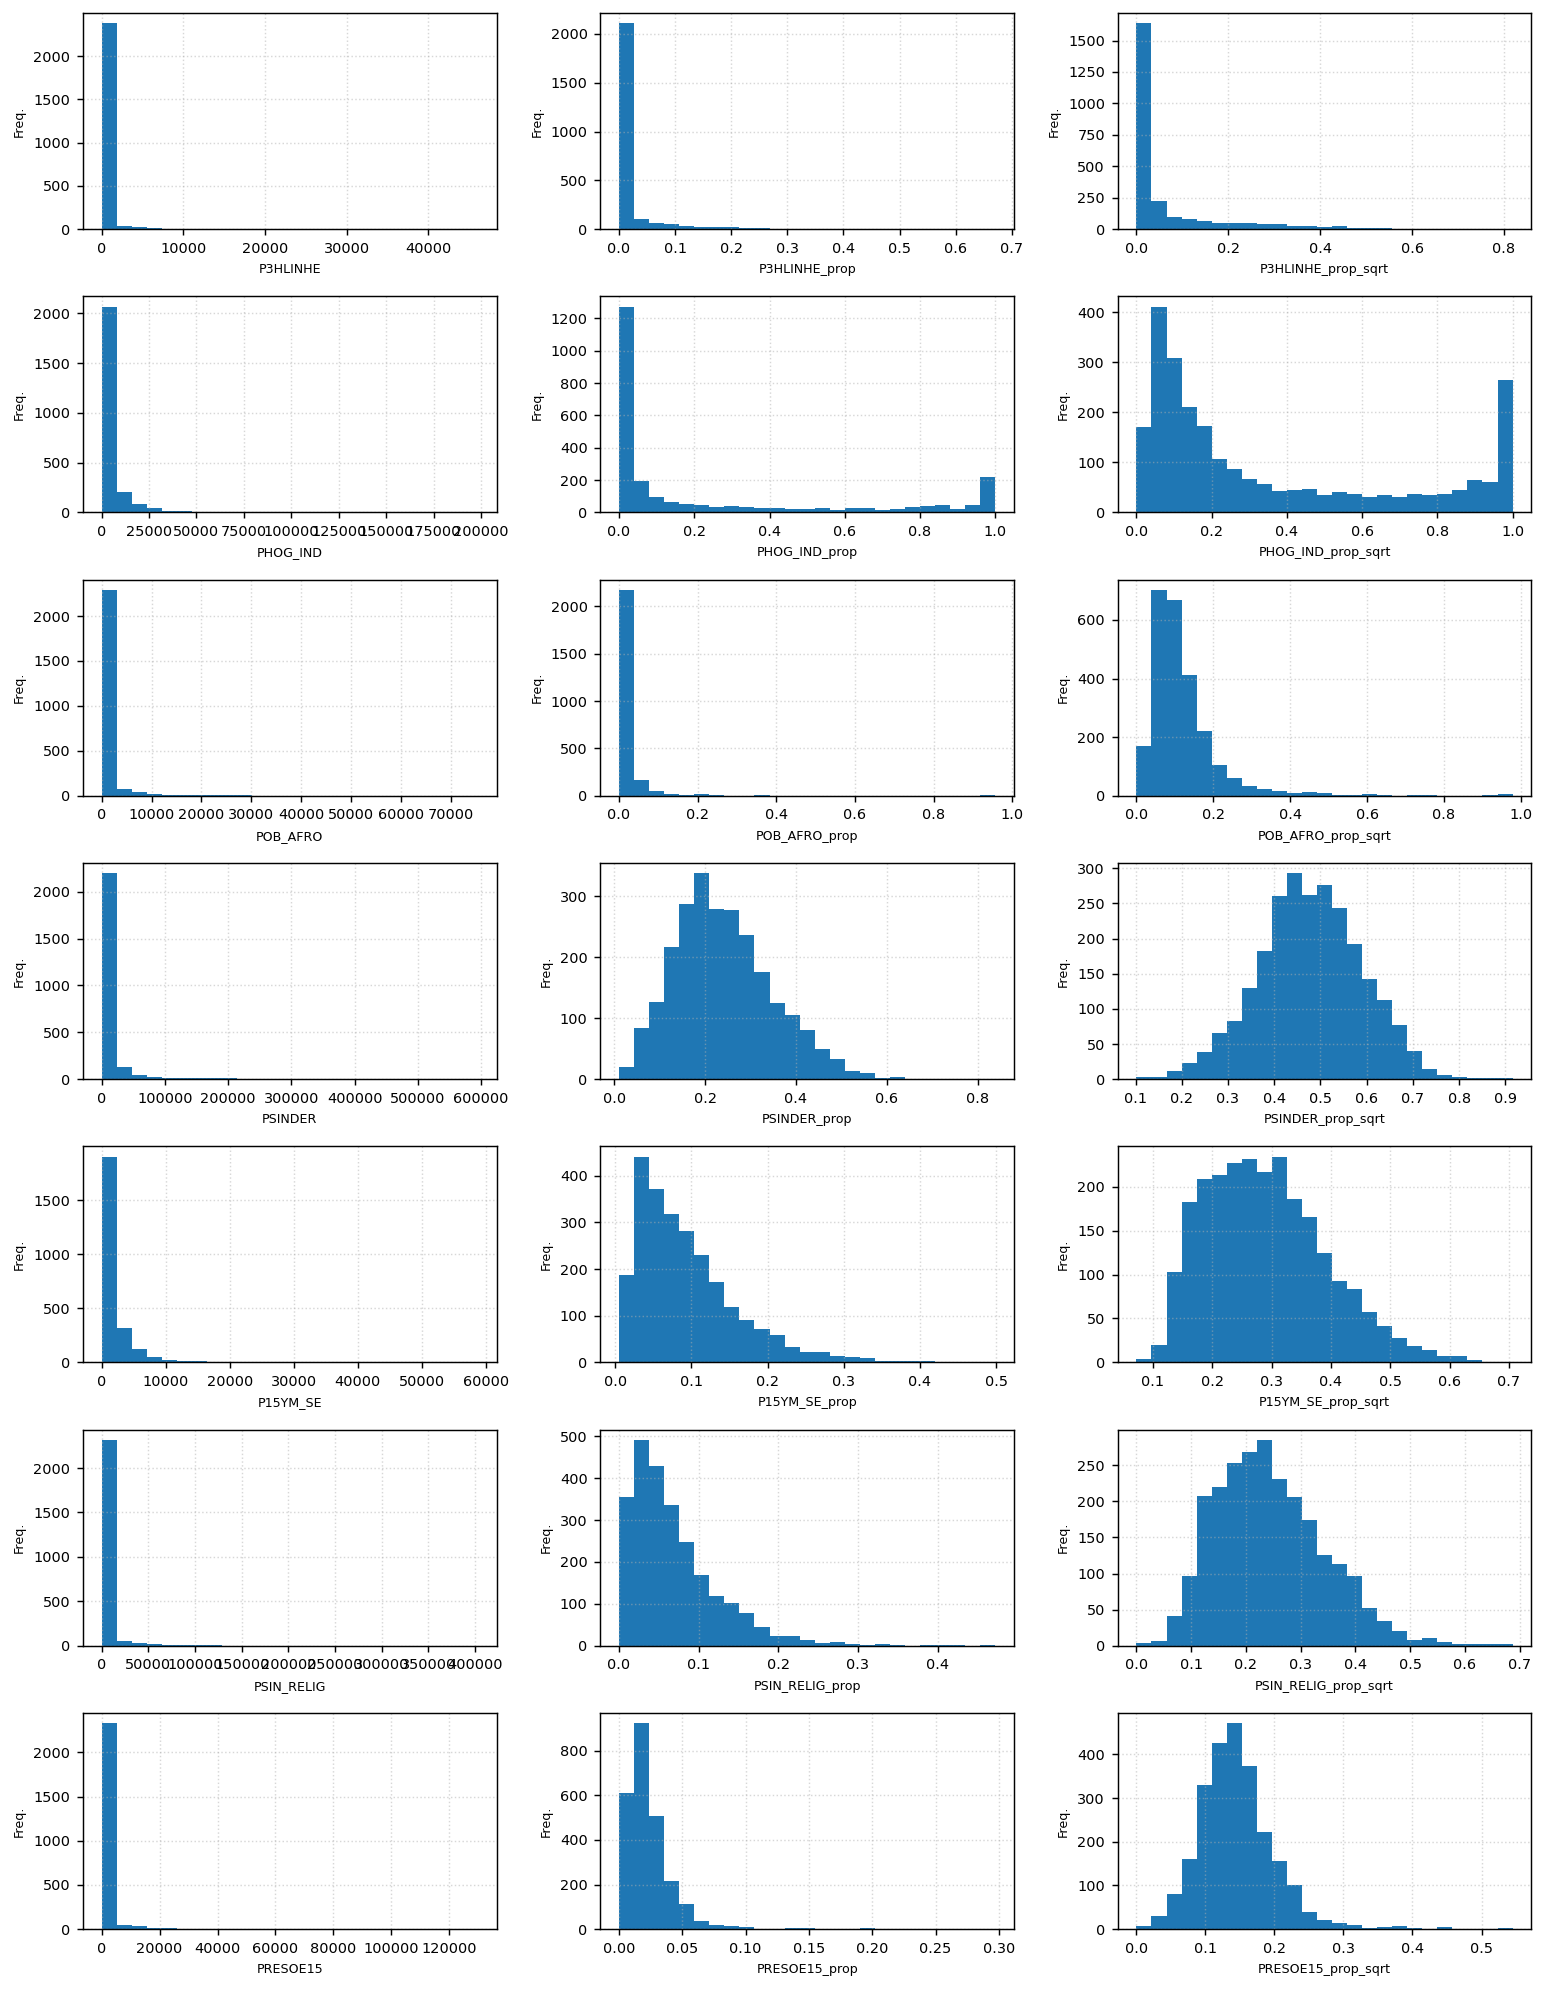

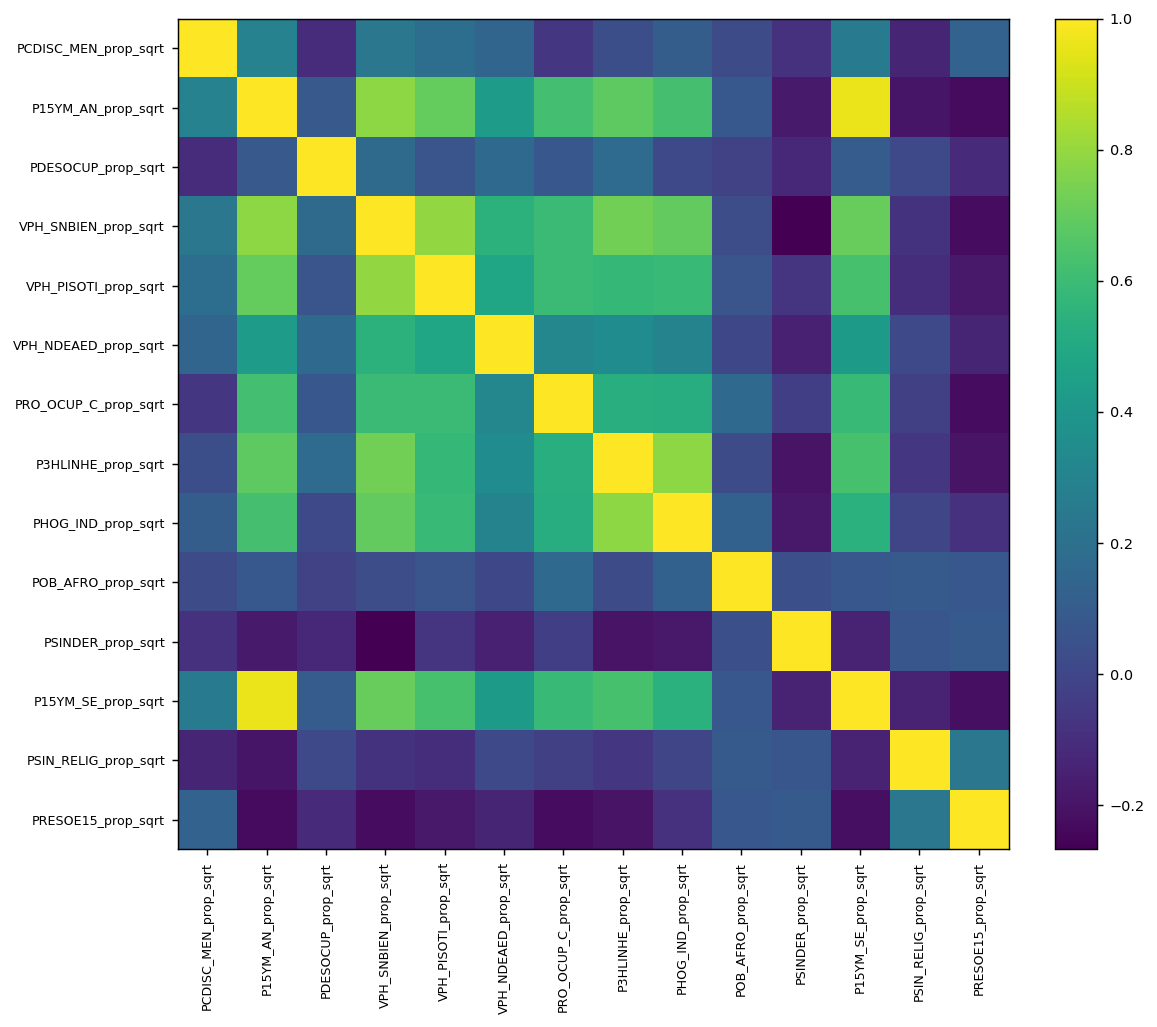

Matriz de correlaciones:


,PCDISC_MEN_prop_sqrt,P15YM_AN_prop_sqrt,PDESOCUP_prop_sqrt,VPH_SNBIEN_prop_sqrt,VPH_PISOTI_prop_sqrt,VPH_NDEAED_prop_sqrt,PRO_OCUP_C_prop_sqrt,P3HLINHE_prop_sqrt,PHOG_IND_prop_sqrt,POB_AFRO_prop_sqrt,PSINDER_prop_sqrt,P15YM_SE_prop_sqrt,PSIN_RELIG_prop_sqrt,PRESOE15_prop_sqrt
PCDISC_MEN_prop_sqrt,1.000000,0.295943,-0.106572,0.234892,0.190641,0.147101,-0.065699,0.037616,0.107840,0.026256,-0.087472,0.253566,-0.136262,0.133632
P15YM_AN_prop_sqrt,0.295943,1.000000,0.086322,0.784913,0.698714,0.434845,0.623375,0.683797,0.627100,0.081884,-0.174158,0.963527,-0.195280,-0.227588
PDESOCUP_prop_sqrt,-0.106572,0.086322,1.000000,0.169363,0.068257,0.165913,0.078478,0.174492,0.013347,-0.022310,-0.125446,0.103439,0.010943,-0.118228
VPH_SNBIEN_prop_sqrt,0.234892,0.784913,0.169363,1.000000,0.796176,0.546668,0.598988,0.728302,0.696117,0.033479,-0.267005,0.705068,-0.082871,-0.223519
VPH_PISOTI_prop_sqrt,0.190641,0.698714,0.068257,0.796176,1.000000,0.484650,0.597897,0.578905,0.592521,0.067695,-0.073981,0.630645,-0.099669,-0.179271
VPH_NDEAED_prop_sqrt,0.147101,0.434845,0.165913,0.546668,0.484650,1.000000,0.317668,0.350939,0.297995,0.009304,-0.149009,0.425423,0.011003,-0.135489
PRO_OCUP_C_prop_sqrt,-0.065699,0.623375,0.078478,0.598988,0.597897,0.317668,1.000000,0.526688,0.521143,0.165375,-0.031109,0.592676,-0.026590,-0.226388
P3HLINHE_prop_sqrt,0.037616,0.683797,0.174492,0.728302,0.578905,0.350939,0.526688,1.000000,0.787081,0.024910,-0.198135,0.629126,-0.064851,-0.199717
PHOG_IND_prop_sqrt,0.107840,0.627100,0.013347,0.696117,0.592521,0.297995,0.521143,0.787081,1.000000,0.128408,-0.182526,0.540454,-0.004544,-0.088724
POB_AFRO_prop_sqrt,0.026256,0.081884,-0.022310,0.033479,0.067695,0.009304,0.165375,0.024910,0.128408,1.000000,0.041708,0.077365,0.091035,0.078648


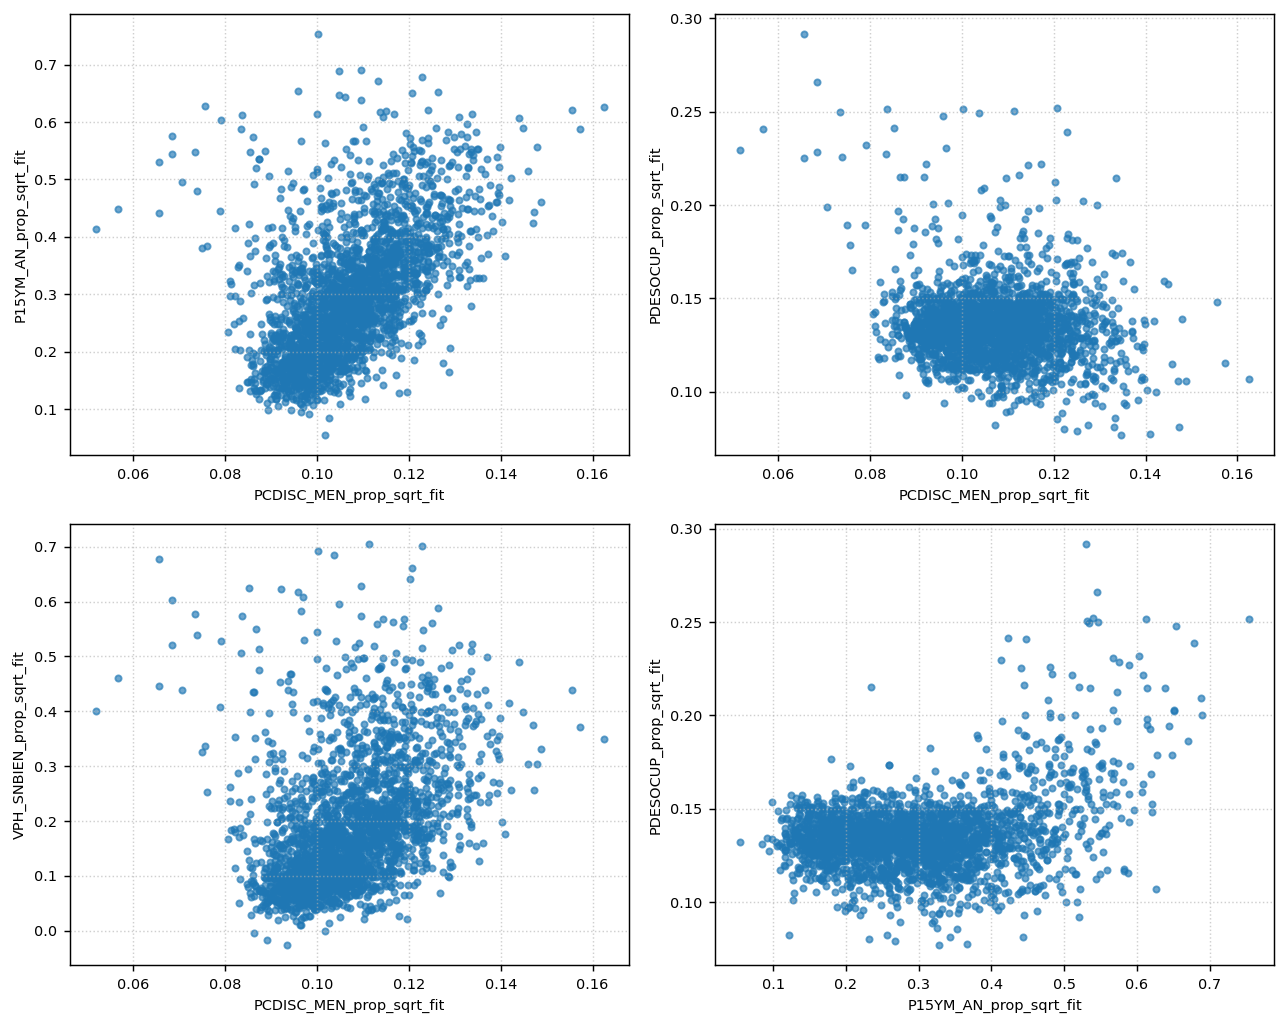

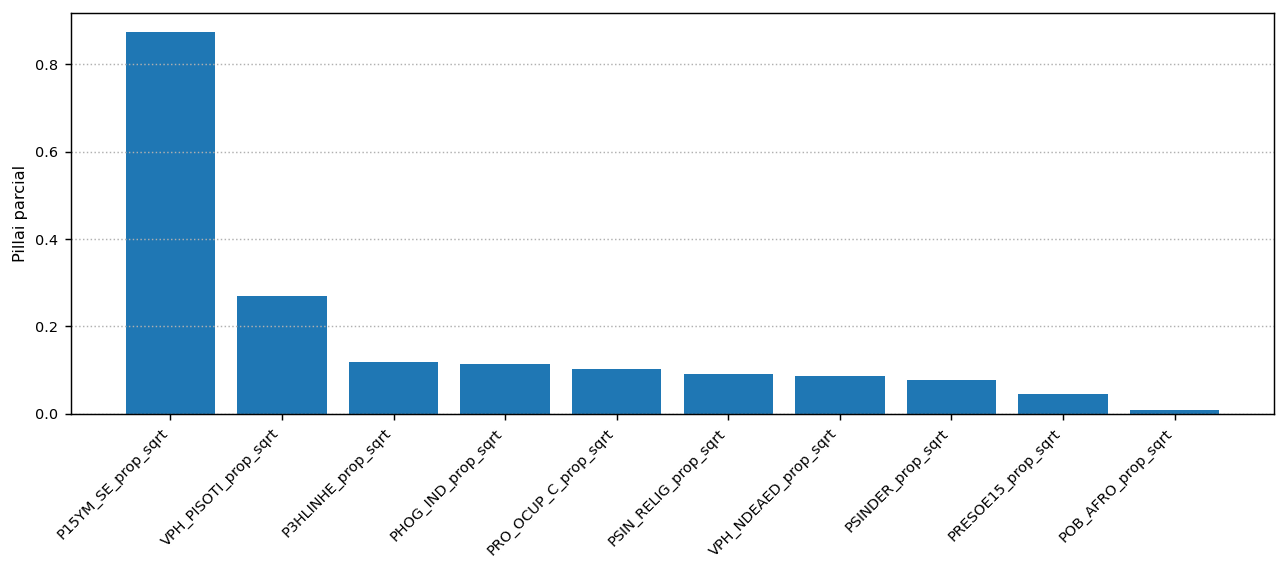

In [18]:
# ==========================================
# CELDA 18 — VISUALIZACIONES DE APOYO
# ==========================================

vars_base = Y_vars + X_vars
vars_prop = Y_prop_vars + X_prop_vars
vars_sqrt = Y_sqrt_vars + X_sqrt_vars

tripletas = list(zip(vars_base, vars_prop, vars_sqrt))
bloques = [tripletas[:7], tripletas[7:14]]

for idx_bloque, bloque in enumerate(bloques, start=1):
    fig, axes = plt.subplots(len(bloque), 3, figsize=(12, 2.2 * len(bloque)))

    if len(bloque) == 1:
        axes = np.array([axes])

    for i, (orig, prop, trans) in enumerate(bloque):
        axes[i, 0].hist(pd.to_numeric(dfm[orig], errors="coerce").dropna(), bins=25)
        axes[i, 0].set_xlabel(orig, fontsize=7)
        axes[i, 0].set_ylabel("Freq.", fontsize=7)
        axes[i, 0].grid(True, linestyle=":", alpha=0.5)

        axes[i, 1].hist(dfm[prop].dropna(), bins=25)
        axes[i, 1].set_xlabel(prop, fontsize=7)
        axes[i, 1].set_ylabel("Freq.", fontsize=7)
        axes[i, 1].grid(True, linestyle=":", alpha=0.5)

        axes[i, 2].hist(dfm[trans].dropna(), bins=25)
        axes[i, 2].set_xlabel(trans, fontsize=7)
        axes[i, 2].set_ylabel("Freq.", fontsize=7)
        axes[i, 2].grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()

vars_corr = Y_sqrt_vars + X_sqrt_vars
corr_mat = dfm[vars_corr].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_mat, aspect="equal")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(vars_corr)), vars_corr, rotation=90, fontsize=7)
plt.yticks(range(len(vars_corr)), vars_corr, fontsize=7)
plt.tight_layout()
plt.show()

corr_df = pd.DataFrame(corr_mat, index=vars_corr, columns=vars_corr)
print("Matriz de correlaciones:")
display(corr_df)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

pair_list = []
for i in range(len(Y_sqrt_vars)):
    for j in range(i + 1, len(Y_sqrt_vars)):
        pair_list.append((Y_sqrt_vars[i], Y_sqrt_vars[j]))

for ax, (yi, yj) in zip(axes, pair_list):
    ax.scatter(dfm[f"{yi}_fit"], dfm[f"{yj}_fit"], s=12, alpha=0.65)
    ax.set_xlabel(f"{yi}_fit", fontsize=8)
    ax.set_ylabel(f"{yj}_fit", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.6)

for ax in axes[len(pair_list):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

if not df_parciales.empty:
    top_plot = df_parciales.sort_values("pillai_trace", ascending=False)

    plt.figure(figsize=(10, 4.5))
    plt.bar(top_plot["variable"], top_plot["pillai_trace"])
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.ylabel("Pillai parcial", fontsize=9)
    plt.grid(True, axis="y", linestyle=":")
    plt.tight_layout()
    plt.show()